## 1. Configuration

# MF34 Legendre Uncertainty Breakdown (Hybrid: EXFOR c0 + ENDF Coefficients)

This notebook shows how **MF34 Legendre coefficient uncertainties** propagate into
differential cross sections. The baseline angular distribution uses a **hybrid approach**:
- **c₀ (normalization)** comes from fitting EXFOR experimental data
- **Higher order coefficients (a_l for l ≥ 1)** come from ENDF MF4 Legendre coefficients
- **MF34 uncertainties** are propagated on the ENDF coefficients

Three evaluation cases are compared (JEFF-4.0, JENDL-5, User ENDF), each with its own
normalization (c0 from EXFOR fit) combined with ENDF angular shape.

## Key Formulas

| Quantity | Expression |
|---|---|
| Baseline | $\frac{d\sigma}{d\Omega}(\mu) = c_0 \left[1 + \sum_{l=1}^{L_{\max}} (2l+1)\, a_l\, P_l(\mu)\right]$ |
| Sensitivity | $\frac{\partial}{\partial a_l}\frac{d\sigma}{d\Omega} = c_0 (2l+1)\, P_l(\mu)$ |
| Individual band | $\delta_l = \lvert c_0 (2l+1)\, P_l(\mu)\, \delta a_l \rvert$ |
| Cumulative band | $\delta = \sqrt{\sum_{l=1}^{L_{\max}} \left[c_0\,(2l+1)\,P_l(\mu)\,\delta a_l\right]^2}$ |

where:
- $c_0$ = EXFOR fit isotropic component (normalization)
- $a_l$ = ENDF MF4 Legendre coefficients (l ≥ 1)
- $\delta a_l$ = MF34 absolute uncertainty for coefficient a_l

In [1]:
# ============================================================================
# USER CONFIGURABLE PARAMETERS
# ============================================================================

# -- ENDF evaluation files --------------------------------------------------
JEFF_FILE  = "/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/endf_files/26-Fe-56g.txt"
JENDL_FILE = "/mnt/c/Users/MONLEON-DE-LA-JAN/Documents/endf_files/260560.jendl5"
USER_FILE  = "/share_snc/snc/JuanMonleon/ENDF_samples/new_test_29/26-Fe-56g_nominal_mg.endf"

# MT number for elastic scattering
MT_NUMBER = 2

# -- EXFOR configuration ----------------------------------------------------
EXFOR_DB_PATH = '/share_snc/snc/JuanMonleon/EXFOR/x4_iron_angular.db'
TARGET_ZAIDS  = [26056, 26000]  # Fe-56 + natural iron

SUPPLEMENTARY_JSON_FILES = [
    '/share_snc/snc/JuanMonleon/EXFOR/data_v1/27673002.json',  # Gkatis (2025)
]

EXCLUDE_EXPERIMENTS = ["32246002"]

MIN_RELATIVE_UNCERTAINTY = 0.03  # 3% minimum uncertainty floor

# -- Normalization rules -----------------------------------------------------
KINNEY_SUBENTRY      = "10571002"
SMITH_SUBENTRY       = "10886002"
ENERGY_THRESHOLD_MEV = 2.5

# -- Physics parameters ------------------------------------------------------
M_PROJ_U = 1.008665   # neutron mass (u)
M_TARG_U = 55.93494   # Fe-56 mass (u)

# TOF parameters for energy bin computation
DELTA_T_NS    = 5.0     # time resolution (ns)
FLIGHT_PATH_M = 27.037  # flight path (m)

# -- Plot settings -----------------------------------------------------------
N_SIGMA     = 1        # number of sigma for uncertainty bands
PLOT_YSCALE = 'log'    # 'linear' or 'log'
SHOW_DIAG_ONLY_BAND = False
EXFOR_PLOT_N_SIGMA   = 2.0
EXFOR_PLOT_MIN_ALPHA = 0.3

# -- Thesis figure formatting ------------------------------------------------
FIGSIZE_GRID     = (6.5, 7.0)   # Individual / cumulative grids (2-col, taller)
FIGSIZE_SINGLE   = (6, 4)  # Summary & cross-case overlay (compact)
FIGSIZE_TRIPTYCH = (6.5, 2.5)   # 1x3 side-by-side comparison

FONTSIZES_2COL = {'axes_label': 9, 'tick_label': 8, 'legend': 8, 'subplot_title': 9}
FONTSIZES_1COL = {'axes_label': 7, 'tick_label': 6, 'legend': 5.5, 'subplot_title': 7}

# Library colors (consistent across all plots)
CASE_COLORS = {'JEFF-4.0': 'tab:blue', 'JENDL-5': 'tab:green', 'This work': 'tab:red'}

# -- Figure saving -----------------------------------------------------------
SAVE_FIGURES = True
FIGURES_OUTPUT_DIR = '/share_snc/snc/JuanMonleon/DA_Figures'
FIGURE_FORMAT = 'png'
FIGURE_DPI = 300

## 2. Imports

In [2]:
import sys
from pathlib import Path
from math import ceil
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from numpy.polynomial.legendre import legval
from scipy.special import legendre

# Ensure kika is on the path
_kika_path = Path().absolute().parent.parent.parent.parent
if str(_kika_path) not in sys.path:
    sys.path.insert(0, str(_kika_path))

import kika
from kika.endf import read_endf
from kika.exfor import read_all_exfor
import kika.exfor as exfor
from kika.plotting.styles import _get_color_palette

from scripts.exfor_utils import (
    build_exfor_cache_from_objects,
    filter_exfor_with_energy_bin,
)
from scripts.resample_AD import (
    compute_energy_resolution_tof as compute_sigma_E,
    sample_legendre_coefficients,
)

# Configure EXFOR database
exfor.configure(db_path=EXFOR_DB_PATH)

# Plotting defaults
plt.rcParams['figure.dpi'] = FIGURE_DPI
KIKA_COLORS = _get_color_palette('light')
EXFOR_MARKERS = ['o', 's', '^', 'v', 'D', 'p', 'h', '*', 'X', '<', '>']

print("Imports OK")

Imports OK


## 3. Utility Functions

These are defined once and reused for every energy.

In [3]:
def save_figure_structured(fig, plot_type, library=None, energy_mev=None, filename=None, yscale=None):
    "Save figure with structured directory organization."
    if not SAVE_FIGURES:
        return
    if energy_mev is None:
        energy_mev = TARGET_ENERGY_MEV
    base_dir = Path(FIGURES_OUTPUT_DIR)
    energy_dir = base_dir / f"E_{energy_mev:.2f}_MeV"
    if plot_type == 'diagnostic':
        subdir = energy_dir / 'diagnostic'
    elif plot_type in ['individual', 'cumulative', 'summary']:
        if library is None:
            raise ValueError(f"library must be specified for {plot_type} plots")
        lib_safe = library.replace(' ', '_').replace('-', '_')
        subdir = energy_dir / lib_safe
    elif plot_type == 'comparison':
        subdir = energy_dir / 'comparison'
    else:
        raise ValueError(f"Unknown plot_type: {plot_type}")
    subdir.mkdir(parents=True, exist_ok=True)
    if filename is None:
        filename = plot_type
    if yscale is not None:
        filename = f"{filename}_{yscale}"
    filepath = subdir / f"{filename}.{FIGURE_FORMAT}"
    fig.savefig(filepath, dpi=FIGURE_DPI, bbox_inches='tight', format=FIGURE_FORMAT)
    print(f"  Saved: {filepath}")


def load_endf_raw(filepath, label):
    "Load an ENDF file (expensive I/O). Run once."
    print(f"  Loading {label} from {filepath} ...")
    endf_obj = read_endf(filepath)
    mt_section = endf_obj.get_file(4).sections[MT_NUMBER]
    energies_ev = np.array(mt_section.legendre_energies)
    mf34 = None
    try:
        mf34 = endf_obj.mf[34].mt[MT_NUMBER].to_ang_covmat()
        print(f"    MF34: {mf34.num_matrices} matrices")
    except Exception as exc:
        print(f"    MF34: not available ({exc})")
    return dict(label=label, endf=endf_obj, mf34=mf34,
                energies_mev=energies_ev / 1e6, mt_section=mt_section)


def select_energy_from_endf(raw_case, target_energy_mev):
    "Select target energy bin from pre-loaded ENDF (cheap). Re-run per energy."
    energies_mev = raw_case['energies_mev']
    target_idx = int(np.argmin(np.abs(energies_mev - target_energy_mev)))
    closest_mev = energies_mev[target_idx]
    endf_coeffs = np.array(raw_case['mt_section'].legendre_coefficients[target_idx])
    L_max = len(endf_coeffs)
    if target_idx > 0:
        bin_lower = (energies_mev[target_idx - 1] + closest_mev) / 2
    else:
        bin_lower = 0.0
    if target_idx < len(energies_mev) - 1:
        bin_upper = (closest_mev + energies_mev[target_idx + 1]) / 2
    else:
        bin_upper = float('inf')
    print(f"  {raw_case['label']}: E={closest_mev:.6f} MeV, L_max={L_max}, "
          f"bin=[{bin_lower:.6f}, {bin_upper:.6f}]")
    return dict(**raw_case, L_max=L_max, endf_coeffs=endf_coeffs,
                target_idx=target_idx, closest_energy_mev=closest_mev,
                bin_lower=bin_lower, bin_upper=bin_upper)


def filter_exfor_for_case(case_data, post_filter_subentry=None):
    "Filter EXFOR for a given case energy bin, optionally restricting to one subentry."
    df, exp_info, kw, diag, _floor_stats = filter_exfor_with_energy_bin(
        exfor_cache=exfor_cache,
        sorted_energies=sorted_exfor_energies,
        bin_lower_mev=case_data['bin_lower'],
        bin_upper_mev=case_data['bin_upper'],
        target_energy_mev=case_data['closest_energy_mev'],
        m_proj_u=M_PROJ_U, m_targ_u=M_TARG_U,
        dedupe_per_experiment=True,
        exclude_experiments=EXCLUDE_EXPERIMENTS,
        min_relative_uncertainty=MIN_RELATIVE_UNCERTAINTY,
        normalize_by_n_points=True,
        max_experiment_weight_fraction=0.5,
    )
    if not df.empty and 'experiment_id' not in df.columns:
        df['experiment_id'] = df['entry'] + '/' + df['subentry']
    if post_filter_subentry is not None and not df.empty:
        entry_str = post_filter_subentry[:5]
        sub_str   = post_filter_subentry[5:]
        mask = (df['entry'] == entry_str) & (df['subentry'] == sub_str)
        if mask.any():
            df  = df[mask].reset_index(drop=True)
            kw  = kw[mask.values] if kw is not None else None
            exp_info = [e for e in exp_info
                        if e.get('entry') == entry_str and e.get('subentry') == sub_str]
        else:
            print(f"    WARNING: subentry {entry_str}/{sub_str} not found; using all data")
    return df, exp_info, kw


def compute_hybrid_baseline(case_data, exfor_df, kernel_weights):
    "Fit EXFOR to get c0, then combine with ENDF Legendre coefficients."
    degree = case_data['L_max']
    endf_coeffs = case_data['endf_coeffs']
    if exfor_df is None or exfor_df.empty or len(exfor_df) < 2:
        print(f"  WARNING: too few EXFOR points ({0 if exfor_df is None else len(exfor_df)})")
        return None
    coef_df, fit_info = sample_legendre_coefficients(
        df=exfor_df, value_col="value", unc_col="unc", mu_col="mu",
        degree=degree, n_samples=1,
        external_weights=kernel_weights,
        ridge_lambda=1e-6, rescale_unc_by_chi2=True,
    )
    c0 = coef_df['c0'].values[0]
    hybrid_coeffs = [c0]
    for l in range(1, degree + 1):
        a_l = endf_coeffs[l - 1]
        c_l = c0 * (2 * l + 1) * a_l
        hybrid_coeffs.append(c_l)
    print(f"  c0 (EXFOR) = {c0:.6f} b/sr, chi2_red = {fit_info['chi2_red']:.2f}")
    return dict(c0=c0, hybrid_coeffs=hybrid_coeffs, endf_coeffs=endf_coeffs,
                fit_info=fit_info, degree=degree)


def propagate_mf34_to_dsigma(mf34_covmat, e_mev, mu_array, endf_coeffs, c0):
    "Propagate MF34 Legendre covariances to dsigma/dOmega uncertainties via sandwich formula."
    if mf34_covmat is None:
        return np.zeros(len(mu_array))
    L_max = len(endf_coeffs)
    e_search = e_mev * 1e6 if getattr(mf34_covmat, 'energy_unit', 'eV') == 'eV' else e_mev
    Cov_abs = np.zeros((L_max, L_max))
    for idx in range(len(mf34_covmat.matrices)):
        l_r = mf34_covmat.l_rows[idx]
        l_c = mf34_covmat.l_cols[idx]
        if l_r < 1 or l_r > L_max or l_c < 1 or l_c > L_max:
            continue
        grid = np.array(mf34_covmat.energy_grids[idx])
        mat = mf34_covmat.matrices[idx]
        k = np.searchsorted(grid, e_search, side='right') - 1
        k = np.clip(k, 0, mat.shape[0] - 1)
        cov_val = mat[k, k]
        if mf34_covmat.is_relative[idx]:
            cov_val *= endf_coeffs[l_r - 1] * endf_coeffs[l_c - 1]
        Cov_abs[l_r - 1, l_c - 1] = cov_val
        if l_r != l_c:
            Cov_abs[l_c - 1, l_r - 1] = cov_val
    S = np.zeros((L_max, len(mu_array)))
    for l in range(1, L_max + 1):
        coeffs_pl = np.zeros(l + 1)
        coeffs_pl[l] = 1.0
        S[l - 1, :] = c0 * (2 * l + 1) * legval(mu_array, coeffs_pl)
    V = Cov_abs @ S
    var_eval = np.sum(S * V, axis=0)
    return np.sqrt(np.maximum(var_eval, 0.0))


def recalculate_chi2(fit_result, exfor_df_all, case_data=None):
    "Calculate chi2 using combined uncertainty."
    if fit_result is None or exfor_df_all is None or exfor_df_all.empty:
        return None
    hybrid_coeffs = fit_result['hybrid_coeffs']
    c0 = fit_result['c0']
    mu_data = exfor_df_all['mu'].values
    y_data = exfor_df_all['value'].values
    sigma_exp = exfor_df_all['unc'].values
    y_pred = legval(mu_data, hybrid_coeffs)
    if case_data is not None and case_data.get('mf34') is not None:
        sigma_eval = propagate_mf34_to_dsigma(
            case_data['mf34'], case_data['closest_energy_mev'],
            mu_data, case_data['endf_coeffs'], c0)
    else:
        sigma_eval = np.zeros_like(sigma_exp)
    sigma_total = np.sqrt(sigma_exp**2 + sigma_eval**2)
    residuals = (y_data - y_pred) / sigma_total
    chi2 = np.sum(residuals**2)
    N = len(y_data)
    residuals_exp = (y_data - y_pred) / sigma_exp
    chi2_exp = np.sum(residuals_exp**2)
    return {'chi2/N': chi2 / N, 'chi2/N_exp_only': chi2_exp / N,
            'chi2_red': chi2 / max(1, N - len(hybrid_coeffs)), 'N': N}


def get_legendre_coefficient_uncertainty(mf34_covmat, endf_data, zaid, mt, energy_mev, order):
    "Get ABSOLUTE uncertainty for a single Legendre coefficient at a given energy."
    if mf34_covmat is None:
        return {'absolute': 0.0, 'relative': 0.0, 'is_relative': False}
    try:
        unc_data = mf34_covmat.get_uncertainties_for_legendre_coefficient(zaid, mt, order)
        if unc_data is None:
            return {'absolute': 0.0, 'relative': 0.0, 'is_relative': False}
        energies    = unc_data['energies']
        unc_values  = unc_data['uncertainties']
        is_relative = unc_data['is_relative']
        energy_ev   = energy_mev * 1e6
        bin_idx = -1
        for i in range(len(energies) - 1):
            if energies[i] <= energy_ev < energies[i + 1]:
                bin_idx = i
                break
        else:
            if abs(energy_ev - energies[-1]) < 1e-6:
                bin_idx = len(unc_values) - 1
        if bin_idx < 0:
            return {'absolute': 0.0, 'relative': 0.0, 'is_relative': False}
        unc_at_energy = unc_values[bin_idx]
        if not is_relative:
            return {'absolute': unc_at_energy, 'relative': 0.0, 'is_relative': False}
        mf4_mt = endf_data.mf[4].mt[mt]
        coeffs_dict = mf4_mt.extract_legendre_coefficients(
            energy_ev, max_legendre_order=order, out_of_range="zero")
        if coeffs_dict is not None and order in coeffs_dict:
            A_l = coeffs_dict[order]
            return {'absolute': unc_at_energy * abs(A_l),
                    'relative': unc_at_energy, 'is_relative': True}
        return {'absolute': 0.0, 'relative': unc_at_energy, 'is_relative': True}
    except Exception as exc:
        print(f"  Warning L={order}: {exc}")
        return {'absolute': 0.0, 'relative': 0.0, 'is_relative': False}


def extract_all_mf34_uncertainties(case_data):
    "Return {order: delta_a_abs} for l = 1 .. L_max."
    result = {}
    for l in range(1, case_data['L_max'] + 1):
        info = get_legendre_coefficient_uncertainty(
            case_data['mf34'], case_data['endf'], 26056, MT_NUMBER,
            case_data['closest_energy_mev'], l)
        result[l] = info['absolute']
    return result


def extract_mf34_covariance_matrix_at_energy(mf34_covmat, endf_data, zaid, mt, energy_mev, L_max):
    "Extract L_max x L_max absolute covariance matrix Cov[a_l, a_k] at one energy."
    cov = np.zeros((L_max, L_max))
    if mf34_covmat is None:
        return cov
    energy_ev = energy_mev * 1e6
    mf4_mt = endf_data.mf[4].mt[mt]
    coeffs_dict = mf4_mt.extract_legendre_coefficients(
        energy_ev, max_legendre_order=L_max, out_of_range="zero")
    for i in range(mf34_covmat.num_matrices):
        if (mf34_covmat.isotope_rows[i] != zaid or
            mf34_covmat.reaction_rows[i] != mt or
            mf34_covmat.isotope_cols[i] != zaid or
            mf34_covmat.reaction_cols[i] != mt):
            continue
        l = mf34_covmat.l_rows[i]
        k = mf34_covmat.l_cols[i]
        if l < 1 or l > L_max or k < 1 or k > L_max:
            continue
        egrid = np.asarray(mf34_covmat.energy_grids[i])
        bin_idx = -1
        for b in range(len(egrid) - 1):
            if egrid[b] <= energy_ev < egrid[b + 1]:
                bin_idx = b
                break
        if bin_idx < 0 and abs(energy_ev - egrid[-1]) < 1e-6:
            bin_idx = len(egrid) - 2
        if bin_idx < 0:
            continue
        value = float(mf34_covmat.matrices[i][bin_idx, bin_idx])
        if mf34_covmat.is_relative[i]:
            a_l = coeffs_dict.get(l, 0.0) if coeffs_dict else 0.0
            a_k = coeffs_dict.get(k, 0.0) if coeffs_dict else 0.0
            value *= a_l * a_k
        cov[l - 1, k - 1] = value
        cov[k - 1, l - 1] = value
    return cov


def extract_all_mf34_covariance(case_data):
    "Extract diagonal uncertainties dict AND full covariance matrix."
    delta_a_dict = extract_all_mf34_uncertainties(case_data)
    cov_matrix = extract_mf34_covariance_matrix_at_energy(
        case_data['mf34'], case_data['endf'], 26056, MT_NUMBER,
        case_data['closest_energy_mev'], case_data['L_max'])
    return delta_a_dict, cov_matrix


def compute_uncertainty_breakdown(fit_result, delta_a_dict, n_sigma, cov_matrix=None, n_points=200):
    "Compute baseline and uncertainty bands."
    c0             = fit_result['c0']
    hybrid_coeffs  = fit_result['hybrid_coeffs']
    L_max          = len(hybrid_coeffs) - 1
    mu             = np.linspace(-1, 1, n_points)
    baseline       = legval(mu, hybrid_coeffs)
    individual = {}
    for l in range(1, L_max + 1):
        da = delta_a_dict.get(l, 0.0)
        individual[l] = np.abs(c0 * (2 * l + 1) * legendre(l)(mu) * da)
    cumulative  = {}
    running_var = np.zeros_like(mu)
    for L in range(1, L_max + 1):
        da = delta_a_dict.get(L, 0.0)
        running_var += (c0 * (2 * L + 1) * legendre(L)(mu) * da) ** 2
        cumulative[L] = np.sqrt(running_var)
    combined = cumulative.get(L_max, np.zeros_like(mu))
    if cov_matrix is not None:
        S = np.column_stack([c0 * (2*l+1) * legendre(l)(mu) for l in range(1, L_max+1)])
        combined_full = np.sqrt(np.maximum(np.sum((S @ cov_matrix) * S, axis=1), 0.0))
    else:
        combined_full = combined
    return dict(mu=mu, baseline=baseline, individual=individual, cumulative=cumulative,
                combined=combined, combined_full=combined_full,
                n_sigma=n_sigma, L_max=L_max, c0=c0)


print("Utility functions defined.")

Utility functions defined.


## 4. Load ENDF Files (run once)

This is the expensive I/O step. The raw ENDF objects stay in memory.

In [4]:
print("Loading ENDF evaluation files (this may take a moment)...")
endf_raw = {
    "JEFF-4.0":  load_endf_raw(JEFF_FILE,  "JEFF-4.0"),
    "JENDL-5":   load_endf_raw(JENDL_FILE, "JENDL-5"),
    "This work":  load_endf_raw(USER_FILE,  "This work"),
}
print(f"\nLoaded {len(endf_raw)} ENDF files.")

Loading ENDF evaluation files (this may take a moment)...
  Loading JEFF-4.0 from /mnt/c/Users/MONLEON-DE-LA-JAN/Documents/endf_files/26-Fe-56g.txt ...


/home/MONLEON-JUAN/kika/kika/endf/parsers/parse_endf.py:94: UserWarning: Skipping MF sections without parsers: [6, 8, 10, 12, 14, 33]. Only parsing: [1, 2, 3, 4, 34]
  warnings.warn(f"Skipping MF sections without parsers: {skipped_mfs}. Only parsing: {parseable_mfs}")


    MF34: 21 matrices
  Loading JENDL-5 from /mnt/c/Users/MONLEON-DE-LA-JAN/Documents/endf_files/260560.jendl5 ...


/home/MONLEON-JUAN/kika/kika/endf/parsers/parse_endf.py:94: UserWarning: Skipping MF sections without parsers: [6, 8, 33]. Only parsing: [1, 2, 3, 4, 34]
  warnings.warn(f"Skipping MF sections without parsers: {skipped_mfs}. Only parsing: {parseable_mfs}")


    MF34: 1 matrices
  Loading This work from /share_snc/snc/JuanMonleon/ENDF_samples/new_test_29/26-Fe-56g_nominal_mg.endf ...
    MF34: 21 matrices

Loaded 3 ENDF files.


## 5. Load EXFOR Database (run once)

In [5]:
print("Loading EXFOR data from database...")
exfor_dict = read_all_exfor(
    target=TARGET_ZAIDS, mt=MT_NUMBER, source="database",
    group_by_energy=False,
    supplementary_json_files=SUPPLEMENTARY_JSON_FILES,
    exclude_experiments=EXCLUDE_EXPERIMENTS,
)
exfor_objects = list(exfor_dict.values())
exfor_cache, sorted_exfor_energies = build_exfor_cache_from_objects(
    exfor_objects, exclude_experiments=EXCLUDE_EXPERIMENTS,
)
print(f"  Datasets        : {len(exfor_objects)}")
print(f"  Unique energies : {len(sorted_exfor_energies)}")
print(f"  Energy range    : [{min(sorted_exfor_energies):.4f}, {max(sorted_exfor_energies):.4f}] MeV")

Loading EXFOR data from database...
  Datasets        : 119
  Unique energies : 22687
  Energy range    : [0.0350, 96.0000] MeV


## 6. Set Target Energy -- Re-run from here

Change `TARGET_ENERGY_MEV` below and re-run all cells from this point.
The ENDF files and EXFOR database are already loaded in memory.

In [25]:
TARGET_ENERGY_MEV = 1.171

print(f"Target energy : {TARGET_ENERGY_MEV} MeV")
print(f"Normalization : {'Kinney' if TARGET_ENERGY_MEV < ENERGY_THRESHOLD_MEV else 'Smith'} "
      f"subentry for JEFF/JENDL, all experiments for This work")

Target energy : 1.171 MeV
Normalization : Kinney subentry for JEFF/JENDL, all experiments for This work


## 7. Energy-Dependent Processing

In [26]:
# --- Select energy from ENDF ---
print("Selecting energy from ENDF evaluations...")
jeff_data  = select_energy_from_endf(endf_raw["JEFF-4.0"],  TARGET_ENERGY_MEV)
jendl_data = select_energy_from_endf(endf_raw["JENDL-5"],   TARGET_ENERGY_MEV)
user_data  = select_energy_from_endf(endf_raw["This work"],  TARGET_ENERGY_MEV)

# --- Common energy bin (union of all libraries) for shared EXFOR filtering ---
common_bin_lower = min(jeff_data['bin_lower'], jendl_data['bin_lower'], user_data['bin_lower'])
common_bin_upper = max(jeff_data['bin_upper'], jendl_data['bin_upper'], user_data['bin_upper'])
common_target_energy = user_data['closest_energy_mev']
common_data = dict(bin_lower=common_bin_lower, bin_upper=common_bin_upper,
                   closest_energy_mev=common_target_energy)
print(f"  Common bin: [{common_bin_lower:.6f}, {common_bin_upper:.6f}] MeV")

# --- Filter EXFOR ---
sub = KINNEY_SUBENTRY if TARGET_ENERGY_MEV < ENERGY_THRESHOLD_MEV else SMITH_SUBENTRY
print(f"\nNormalization subentry: {sub}")

print(f"\nFiltering EXFOR ...")
jeff_exfor,  jeff_exp_info,  jeff_kw  = filter_exfor_for_case(jeff_data,  sub)
jendl_exfor, jendl_exp_info, jendl_kw = filter_exfor_for_case(jendl_data, sub)
user_exfor,  user_exp_info,  user_kw  = filter_exfor_for_case(user_data,  None)
print(f"  JEFF-4.0 : {len(jeff_exfor)} pts, JENDL-5: {len(jendl_exfor)} pts, This work: {len(user_exfor)} pts")

# ALL in-bin EXFOR (no subentry filter) — shared across all libraries
shared_exfor_all, shared_exp_info_all, _ = filter_exfor_for_case(common_data, None)

# --- Extended EXFOR (nearby energy points for summary plots) — shared ---
print(f"\nBuilding extended EXFOR ...")
sigma_E_mev = compute_sigma_E(
    common_target_energy, delta_t_ns=DELTA_T_NS, flight_path_m=FLIGHT_PATH_M)

# Use wider bin to capture nearby experiments for plotting
wide_lower = common_target_energy - EXFOR_PLOT_N_SIGMA * sigma_E_mev
wide_upper = common_target_energy + EXFOR_PLOT_N_SIGMA * sigma_E_mev
ext_df, ext_exp_info, _, _, _ = filter_exfor_with_energy_bin(
    exfor_cache=exfor_cache, sorted_energies=sorted_exfor_energies,
    bin_lower_mev=wide_lower, bin_upper_mev=wide_upper,
    target_energy_mev=common_target_energy,
    m_proj_u=M_PROJ_U, m_targ_u=M_TARG_U,
    dedupe_per_experiment=False,
    exclude_experiments=EXCLUDE_EXPERIMENTS,
    min_relative_uncertainty=MIN_RELATIVE_UNCERTAINTY,
    max_experiment_weight_fraction=1.0,
)
# Gaussian kernel weights for plot transparency
if not ext_df.empty and sigma_E_mev > 0:
    ext_kw = np.exp(-0.5 * ((ext_df['exfor_energy_mev'] - common_target_energy) / sigma_E_mev) ** 2).values
else:
    ext_kw = np.ones(len(ext_df))

ext_exfor_data = {}
if not ext_df.empty:
    if 'experiment_id' not in ext_df.columns:
        ext_df['experiment_id'] = ext_df['entry'] + '/' + ext_df['subentry']
    ext_df['in_bin'] = (
        (ext_df['exfor_energy_mev'] >= common_bin_lower) &
        (ext_df['exfor_energy_mev'] <= common_bin_upper))
    target_e = common_target_energy
    for eid in ext_df.loc[ext_df['in_bin'], 'experiment_id'].unique():
        exp_in_bin = (ext_df['experiment_id'] == eid) & ext_df['in_bin']
        unique_energies = ext_df.loc[exp_in_bin, 'exfor_energy_mev'].unique()
        if len(unique_energies) > 1:
            closest_energy = unique_energies[np.argmin(np.abs(unique_energies - target_e))]
            demote = exp_in_bin & (ext_df['exfor_energy_mev'] != closest_energy)
            ext_df.loc[demote, 'in_bin'] = False
    max_kw = ext_kw.max() if len(ext_kw) > 0 else 1.0
    norm_kw = ext_kw / max_kw if max_kw > 0 else np.ones_like(ext_kw)
    ext_df['plot_alpha'] = EXFOR_PLOT_MIN_ALPHA + norm_kw * (0.9 - EXFOR_PLOT_MIN_ALPHA)
    ext_df.loc[ext_df['in_bin'], 'plot_alpha'] = 0.9
    all_exp_ids = ext_df['experiment_id'].unique()
    in_bin_exp_ids = ext_df.loc[ext_df['in_bin'], 'experiment_id'].unique().tolist()
    nearby_only_exp_ids = [e for e in all_exp_ids if e not in in_bin_exp_ids]
    ordered_exp_ids = in_bin_exp_ids + nearby_only_exp_ids
    exp_visual_map = {}
    for i, eid in enumerate(ordered_exp_ids):
        exp_visual_map[eid] = (KIKA_COLORS[i % len(KIKA_COLORS)],
                               EXFOR_MARKERS[i % len(EXFOR_MARKERS)])
    exp_label_map = {}
    for info in ext_exp_info:
        eid = f"{info.get('entry', '')}/{info.get('subentry', '')}"
        exp_label_map[eid] = f"{info.get('author', eid)} ({info.get('year', '?')})"
    for eid in ordered_exp_ids:
        if eid not in exp_label_map:
            exp_label_map[eid] = eid
    shared_ext = dict(
        ext_df=ext_df, exp_visual_map=exp_visual_map,
        exp_label_map=exp_label_map, in_bin_set=set(in_bin_exp_ids))
    n_nearby = (~ext_df['in_bin']).sum()
    n_inbin = ext_df['in_bin'].sum()
    print(f"  Shared: {n_inbin} in-bin + {n_nearby} nearby")
    for case_label in ["JEFF-4.0", "JENDL-5", "This work"]:
        ext_exfor_data[case_label] = shared_ext

# --- Hybrid baselines ---
print(f"\nComputing hybrid baselines ...")
jeff_fit  = compute_hybrid_baseline(jeff_data,  jeff_exfor,  jeff_kw)
jendl_fit = compute_hybrid_baseline(jendl_data, jendl_exfor, jendl_kw)
user_fit  = compute_hybrid_baseline(user_data,  user_exfor,  user_kw)

# --- Recalculate chi2 ---
print(f"\nRecalculating chi2 (combined sigma) ...")
for tag, fit, cdata in [
    ("JEFF-4.0", jeff_fit, jeff_data),
    ("JENDL-5", jendl_fit, jendl_data),
    ("This work", user_fit, user_data)]:
    if fit is not None:
        chi2_all = recalculate_chi2(fit, shared_exfor_all, cdata)
        fit['chi2_all'] = chi2_all
        if chi2_all:
            print(f"  {tag}: chi2/N = {chi2_all['chi2/N']:.3f} (N={chi2_all['N']})")
    else:
        print(f"  {tag}: fit failed")

# --- MF34 uncertainties ---
print(f"\nExtracting MF34 uncertainties ...")
jeff_delta_a,  jeff_cov  = extract_all_mf34_covariance(jeff_data)
jendl_delta_a, jendl_cov = extract_all_mf34_covariance(jendl_data)
user_delta_a,  user_cov  = extract_all_mf34_covariance(user_data)

# --- Uncertainty breakdown ---
print(f"\nComputing uncertainty breakdown ...")
all_results = {}
case_fits   = {'JEFF-4.0': jeff_fit, 'JENDL-5': jendl_fit, 'This work': user_fit}
case_exfor_data = {
    'JEFF-4.0':  dict(exfor=jeff_exfor,  exp_info=jeff_exp_info,
                      exfor_all=shared_exfor_all, exp_info_all=shared_exp_info_all),
    'JENDL-5':   dict(exfor=jendl_exfor, exp_info=jendl_exp_info,
                      exfor_all=shared_exfor_all, exp_info_all=shared_exp_info_all),
    'This work':  dict(exfor=user_exfor,  exp_info=user_exp_info,
                      exfor_all=shared_exfor_all, exp_info_all=shared_exp_info_all),
}
case_endf_data = {'JEFF-4.0': jeff_data, 'JENDL-5': jendl_data, 'This work': user_data}
case_delta_a   = {'JEFF-4.0': jeff_delta_a, 'JENDL-5': jendl_delta_a, 'This work': user_delta_a}
case_cov       = {'JEFF-4.0': jeff_cov, 'JENDL-5': jendl_cov, 'This work': user_cov}

for tag, fit, da, cov in [("JEFF-4.0", jeff_fit, jeff_delta_a, jeff_cov),
                           ("JENDL-5", jendl_fit, jendl_delta_a, jendl_cov),
                           ("This work", user_fit, user_delta_a, user_cov)]:
    if fit is not None:
        all_results[tag] = compute_uncertainty_breakdown(fit, da, N_SIGMA, cov_matrix=cov)
        r = all_results[tag]
        print(f"  {tag}: L_max={r['L_max']}, max diag={r['combined'].max():.4e}, "
              f"max full={r['combined_full'].max():.4e}")
    else:
        print(f"  {tag}: SKIP (fit failed)")

case_keys = [k for k in ["JEFF-4.0", "JENDL-5", "This work"] if k in all_results]
print(f"\nProcessing complete. Available cases: {case_keys}")

Selecting energy from ENDF evaluations...
  JEFF-4.0: E=1.171000 MeV, L_max=6, bin=[1.170500, 1.171500]
  JENDL-5: E=1.171000 MeV, L_max=6, bin=[1.170000, 1.171500]
  This work: E=1.171000 MeV, L_max=4, bin=[1.170500, 1.171500]
  Common bin: [1.170000, 1.171500] MeV

Normalization subentry: 10571002

Filtering EXFOR ...
  JEFF-4.0 : 8 pts, JENDL-5: 8 pts, This work: 22 pts

Building extended EXFOR ...
  Shared: 24 in-bin + 746 nearby

Computing hybrid baselines ...
  c0 (EXFOR) = 0.136501 b/sr, chi2_red = 0.07
  c0 (EXFOR) = 0.136501 b/sr, chi2_red = 0.07
  c0 (EXFOR) = 0.133856 b/sr, chi2_red = 3.84

Recalculating chi2 (combined sigma) ...
  JEFF-4.0: chi2/N = 3.540 (N=24)
  JENDL-5: chi2/N = 6.751 (N=24)
  This work: chi2/N = 1.695 (N=24)

Extracting MF34 uncertainties ...

Computing uncertainty breakdown ...
  JEFF-4.0: L_max=6, max diag=8.9884e-03, max full=1.0426e-02
  JENDL-5: L_max=6, max diag=5.5695e-03, max full=5.5695e-03
  This work: L_max=4, max diag=1.4140e-02, max full=1.

## 8. Plotting Functions

In [27]:
def _add_shared_legend(fig, ax_or_axes, fs, ncols_fig=2):
    "Add a shared legend below all subplots."
    handles, labels = [], []
    seen = set()
    axes_list = [ax_or_axes] if not hasattr(ax_or_axes, '__iter__') else np.ravel(ax_or_axes)
    for ax in axes_list:
        if not ax.get_visible():
            continue
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in seen:
                handles.append(h)
                labels.append(l)
                seen.add(l)
    if not handles:
        return
    legend_bottom_frac = 0.12 if ncols_fig > 1 else 0.08
    fig.tight_layout(rect=[0, legend_bottom_frac, 1, 1])
    legend_ncol = min(4, len(labels)) if ncols_fig > 1 else min(3, len(labels))
    fig.legend(
        handles, labels,
        loc='upper center',
        bbox_to_anchor=(0.5, legend_bottom_frac - 0.01),
        ncol=legend_ncol,
        fontsize=fs['legend'],
        frameon=True,
        fancybox=True,
    )


def plot_exfor_overlay(ax, exfor_df, exp_info, ms=4, alpha=0.8, capsize=2, mew=0.5):
    "Overlay EXFOR data coloured by experiment."
    if exfor_df is None or exfor_df.empty:
        return
    for i, eid in enumerate(exfor_df['experiment_id'].unique()):
        m = exfor_df['experiment_id'] == eid
        info = next((e for e in exp_info
                     if f"{e.get('entry','')}/{e.get('subentry','')}" == eid), {})
        ax.errorbar(exfor_df.loc[m, 'mu'], exfor_df.loc[m, 'value'],
                    yerr=exfor_df.loc[m, 'unc'],
                    fmt=EXFOR_MARKERS[i % len(EXFOR_MARKERS)],
                    color=KIKA_COLORS[i % len(KIKA_COLORS)],
                    label=f"{info.get('author', eid)} ({info.get('year','?')})",
                    capsize=capsize, markersize=ms, alpha=alpha, markeredgewidth=mew)


def plot_individual_grid(results, exfor_df, exp_info, label, yscale='log',
                         band_color='tab:blue', figsize=None, fs=None):
    "Grid of subplots (2-column) -- one per Legendre order, individual band."
    fs = fs or FONTSIZES_2COL
    figsize = figsize or FIGSIZE_GRID
    L_max = results['L_max']
    ncols = 2
    nrows = ceil(L_max / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    mu = results['mu']; bl = results['baseline']; ns = results['n_sigma']

    for l in range(1, L_max + 1):
        row, col = (l - 1) // ncols, (l - 1) % ncols
        ax = axes[row, col]
        band = results['individual'][l]
        ax.fill_between(mu, bl - ns * band, bl + ns * band,
                        alpha=0.4, color=band_color,
                        label=f'{label} $\\pm{ns}\\sigma$' if l == 1 else None)
        ax.plot(mu, bl, 'k-', lw=1.2, label='Baseline' if l == 1 else None)
        if l == 1:
            plot_exfor_overlay(ax, exfor_df, exp_info, ms=3, alpha=0.6, capsize=2)
        else:
            # Plot EXFOR without labels to avoid legend duplication
            if exfor_df is not None and not exfor_df.empty:
                for i, eid in enumerate(exfor_df['experiment_id'].unique()):
                    m = exfor_df['experiment_id'] == eid
                    ax.errorbar(exfor_df.loc[m, 'mu'], exfor_df.loc[m, 'value'],
                                yerr=exfor_df.loc[m, 'unc'],
                                fmt=EXFOR_MARKERS[i % len(EXFOR_MARKERS)],
                                color=KIKA_COLORS[i % len(KIKA_COLORS)],
                                capsize=2, markersize=3, alpha=0.6, markeredgewidth=0.5)

        ax.set_title(f'$L = {l}$', fontsize=fs['subplot_title'])
        if yscale == 'log':
            ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=fs['tick_label'])

        # Edge-only labels
        if col == 0:
            ax.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=fs['axes_label'])
        else:
            ax.set_ylabel('')
        if row == nrows - 1:
            ax.set_xlabel(r'$\cos(\theta_{\rm CM})$', fontsize=fs['axes_label'])
        else:
            ax.set_xlabel('')

    for idx in range(L_max, nrows * ncols):
        axes[idx // ncols, idx % ncols].set_visible(False)

    _add_shared_legend(fig, axes, fs, ncols_fig=ncols)
    return fig


def plot_cumulative_grid(results, exfor_df, exp_info, label, yscale='log',
                         band_color='tab:green', figsize=None, fs=None):
    "Grid of subplots (2-column) -- one per cumulative max order."
    fs = fs or FONTSIZES_2COL
    figsize = figsize or FIGSIZE_GRID
    L_max = results['L_max']
    ncols = 2
    nrows = ceil(L_max / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    mu = results['mu']; bl = results['baseline']; ns = results['n_sigma']

    for L in range(1, L_max + 1):
        row, col = (L - 1) // ncols, (L - 1) % ncols
        ax = axes[row, col]
        band = results['cumulative'][L]
        ax.fill_between(mu, bl - ns * band, bl + ns * band,
                        alpha=0.4, color=band_color,
                        label=f'{label} $\\pm{ns}\\sigma$' if L == 1 else None)
        ax.plot(mu, bl, 'k-', lw=1.2, label='Baseline' if L == 1 else None)
        if L == 1:
            plot_exfor_overlay(ax, exfor_df, exp_info, ms=3, alpha=0.6, capsize=2)
        else:
            if exfor_df is not None and not exfor_df.empty:
                for i, eid in enumerate(exfor_df['experiment_id'].unique()):
                    m = exfor_df['experiment_id'] == eid
                    ax.errorbar(exfor_df.loc[m, 'mu'], exfor_df.loc[m, 'value'],
                                yerr=exfor_df.loc[m, 'unc'],
                                fmt=EXFOR_MARKERS[i % len(EXFOR_MARKERS)],
                                color=KIKA_COLORS[i % len(KIKA_COLORS)],
                                capsize=2, markersize=3, alpha=0.6, markeredgewidth=0.5)

        ax.set_title(f'$L \\leq {L}$', fontsize=fs['subplot_title'])
        if yscale == 'log':
            ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=fs['tick_label'])

        if col == 0:
            ax.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=fs['axes_label'])
        else:
            ax.set_ylabel('')
        if row == nrows - 1:
            ax.set_xlabel(r'$\cos(\theta_{\rm CM})$', fontsize=fs['axes_label'])
        else:
            ax.set_xlabel('')

    for idx in range(L_max, nrows * ncols):
        axes[idx // ncols, idx % ncols].set_visible(False)

    _add_shared_legend(fig, axes, fs, ncols_fig=ncols)
    return fig


def plot_summary(results, exfor_df, exp_info, label, yscale='log',
                 ext_data=None, band_color='tab:orange', figsize=None, fs=None):
    "Single plot with combined band + EXFOR (with optional nearby EXFOR overlay)."
    fs = fs or FONTSIZES_2COL
    figsize = figsize or FIGSIZE_SINGLE
    fig, ax = plt.subplots(figsize=figsize)
    mu = results['mu']; bl = results['baseline']; ns = results['n_sigma']
    band_full = results.get('combined_full', results['combined'])
    band_diag = results['combined']
    has_cross_corr = not np.allclose(band_full, band_diag, rtol=1e-6)

    band_label = (f'{label} $\\pm{ns}\\sigma$ (full cov)' if has_cross_corr
                  else f'{label} $\\pm{ns}\\sigma$')
    ax.fill_between(mu, bl - ns * band_full, bl + ns * band_full,
                    alpha=0.35, color=band_color, label=band_label)
    ax.plot(mu, bl, 'k-', lw=1.5, label='Baseline')

    if has_cross_corr and SHOW_DIAG_ONLY_BAND:
        ax.plot(mu, bl - ns * band_diag, '--', color=band_color, lw=0.8, alpha=0.7,
                label=f'$\\pm{ns}\\sigma$ (diag only)')
        ax.plot(mu, bl + ns * band_diag, '--', color=band_color, lw=0.8, alpha=0.7)

    if ext_data is not None:
        edf = ext_data['ext_df']
        vmap = ext_data['exp_visual_map']
        lmap = ext_data['exp_label_map']
        _nearby_placed = False
        df_near = edf[~edf['in_bin']]
        for eid in df_near['experiment_id'].unique():
            mask = df_near['experiment_id'] == eid
            df_exp = df_near[mask]
            _, marker = vmap[eid]
            avg_alpha = df_exp['plot_alpha'].median()
            lbl = (f'Nearby EXFOR ({EXFOR_PLOT_N_SIGMA:.0f}$\\sigma_E$ window)'
                   if not _nearby_placed else None)
            _nearby_placed = True
            ax.errorbar(df_exp['mu'], df_exp['value'], yerr=df_exp['unc'],
                        fmt=marker, color='0.55', label=lbl,
                        capsize=2, markersize=3, alpha=avg_alpha,
                        markerfacecolor='none', markeredgewidth=0.6, markeredgecolor='0.55',
                        elinewidth=0.5, ecolor='0.7')
        df_in = edf[edf['in_bin']]
        for eid in df_in['experiment_id'].unique():
            mask = df_in['experiment_id'] == eid
            df_exp = df_in[mask]
            color, marker = vmap[eid]
            ax.errorbar(df_exp['mu'], df_exp['value'], yerr=df_exp['unc'],
                        fmt=marker, color=color, label=lmap.get(eid, eid),
                        capsize=2, markersize=4, alpha=0.9, markeredgewidth=0.5)
    else:
        plot_exfor_overlay(ax, exfor_df, exp_info)

    ax.set_xlabel(r'$\cos(\theta_{\rm CM})$', fontsize=fs['axes_label'])
    ax.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=fs['axes_label'])
    ax.tick_params(labelsize=fs['tick_label'])
    ax.grid(True, alpha=0.3)
    if yscale == 'log':
        ax.set_yscale('log')

    _add_shared_legend(fig, ax, fs, ncols_fig=1)
    return fig


def plot_cross_case_comparison(all_results, case_keys, ext_exfor_data,
                               yscale='log', figsize=None, fs=None):
    "Overlay all libraries on a single plot with a common legend."
    fs = fs or FONTSIZES_2COL
    figsize = figsize or FIGSIZE_SINGLE
    fig, ax = plt.subplots(figsize=figsize)

    for key in case_keys:
        r = all_results[key]
        mu, bl, ns = r['mu'], r['baseline'], r['n_sigma']
        band = r.get('combined_full', r['combined'])
        color = CASE_COLORS.get(key, 'tab:orange')

        ax.fill_between(mu, bl - ns * band, bl + ns * band,
                        alpha=0.25, color=color)
        ax.plot(mu, bl, '-', color=color, lw=1.5,
                label=f'{key} $\\pm{ns}\\sigma$')

    # Overlay EXFOR from "This work"
    ext_data = ext_exfor_data.get("This work")
    if ext_data is not None:
        edf = ext_data['ext_df']
        vmap = ext_data['exp_visual_map']
        lmap = ext_data['exp_label_map']
        df_in = edf[edf['in_bin']]
        for eid in df_in['experiment_id'].unique():
            mask = df_in['experiment_id'] == eid
            df_exp = df_in[mask]
            color, marker = vmap[eid]
            ax.errorbar(df_exp['mu'], df_exp['value'], yerr=df_exp['unc'],
                        fmt=marker, color=color, label=lmap.get(eid, eid),
                        capsize=2, markersize=4, alpha=0.9, markeredgewidth=0.5,
                        zorder=10)

    ax.set_xlabel(r'$\cos(\theta_{\rm CM})$', fontsize=fs['axes_label'])
    ax.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=fs['axes_label'])
    ax.tick_params(labelsize=fs['tick_label'])
    ax.grid(True, alpha=0.3)
    if yscale == 'log':
        ax.set_yscale('log')

    _add_shared_legend(fig, ax, fs, ncols_fig=1)
    return fig


def plot_cross_case_triptych(all_results, case_keys, case_exfor_data,
                             ext_exfor_data, yscale='log', figsize=None, fs=None):
    "1x3 side-by-side: each panel shows one library's combined band + EXFOR."
    fs = fs or FONTSIZES_2COL
    figsize = figsize or FIGSIZE_TRIPTYCH
    n = len(case_keys)
    fig, axes = plt.subplots(1, n, figsize=figsize, sharey=True, squeeze=False)

    # Track which EXFOR labels have been placed across panels
    exfor_labels_placed = set()
    
    # Store handles and labels for manual legend construction
    library_handles = []
    library_labels = []
    exfor_handles = []
    exfor_labels = []

    for idx, key in enumerate(case_keys):
        ax = axes[0, idx]
        r = all_results[key]
        mu, bl, ns = r['mu'], r['baseline'], r['n_sigma']
        band = r.get('combined_full', r['combined'])
        color = CASE_COLORS.get(key, 'tab:orange')

        # Every panel gets a labeled band line (one per library, like the overlay)
        ax.fill_between(mu, bl - ns * band, bl + ns * band,
                        alpha=0.25, color=color)
        line = ax.plot(mu, bl, '-', color=color, lw=1.2)[0]
        
        # Collect library handle/label
        library_handles.append(line)
        library_labels.append(f'{key} $\\pm{ns}\\sigma$')

        # In-bin EXFOR for this case
        ext_data = ext_exfor_data.get(key)
        if ext_data is not None:
            edf = ext_data['ext_df']
            vmap = ext_data['exp_visual_map']
            lmap = ext_data['exp_label_map']
            df_in = edf[edf['in_bin']]
            for eid in df_in['experiment_id'].unique():
                mask = df_in['experiment_id'] == eid
                df_exp = df_in[mask]
                ec, marker = vmap[eid]
                lbl_text = lmap.get(eid, eid)
                if lbl_text not in exfor_labels_placed:
                    exfor_labels_placed.add(lbl_text)
                    # Plot with invisible label to collect handle
                    err_container = ax.errorbar(df_exp['mu'], df_exp['value'], yerr=df_exp['unc'],
                                fmt=marker, color=ec,
                                capsize=2, markersize=3, alpha=0.9, markeredgewidth=0.5,
                                zorder=10)
                    exfor_handles.append(err_container)
                    exfor_labels.append(lbl_text)
                else:
                    # Plot without label
                    ax.errorbar(df_exp['mu'], df_exp['value'], yerr=df_exp['unc'],
                                fmt=marker, color=ec,
                                capsize=2, markersize=3, alpha=0.9, markeredgewidth=0.5,
                                zorder=10)

        if yscale == 'log':
            ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=fs['tick_label'])

        # Edge-only labels
        if idx == 0:
            ax.set_ylabel(r'$d\sigma/d\Omega$ (b/sr)', fontsize=fs['axes_label'])
        else:
            ax.set_ylabel('')
        ax.set_xlabel(r'$\cos(\theta_{\rm CM})$', fontsize=fs['axes_label'])

    # Manual legend construction: libraries first, then EXFOR (matching overlay order)
    all_handles = library_handles + exfor_handles
    all_labels = library_labels + exfor_labels
    
    legend_bottom_frac = 0.12
    fig.tight_layout(rect=[0, legend_bottom_frac, 1, 1])
    legend_ncol = min(4, len(all_labels))
    fig.legend(
        all_handles, all_labels,
        loc='upper center',
        bbox_to_anchor=(0.5, legend_bottom_frac - 0.01),
        ncol=legend_ncol,
        fontsize=fs['legend'],
        frameon=True,
        fancybox=True,
    )
    return fig


print("Plotting functions defined.")

Plotting functions defined.


## 9. Diagnostic: Verify EXFOR Fits

  Saved: /share_snc/snc/JuanMonleon/DA_Figures/E_1.17_MeV/diagnostic/exfor_fit_verification.png


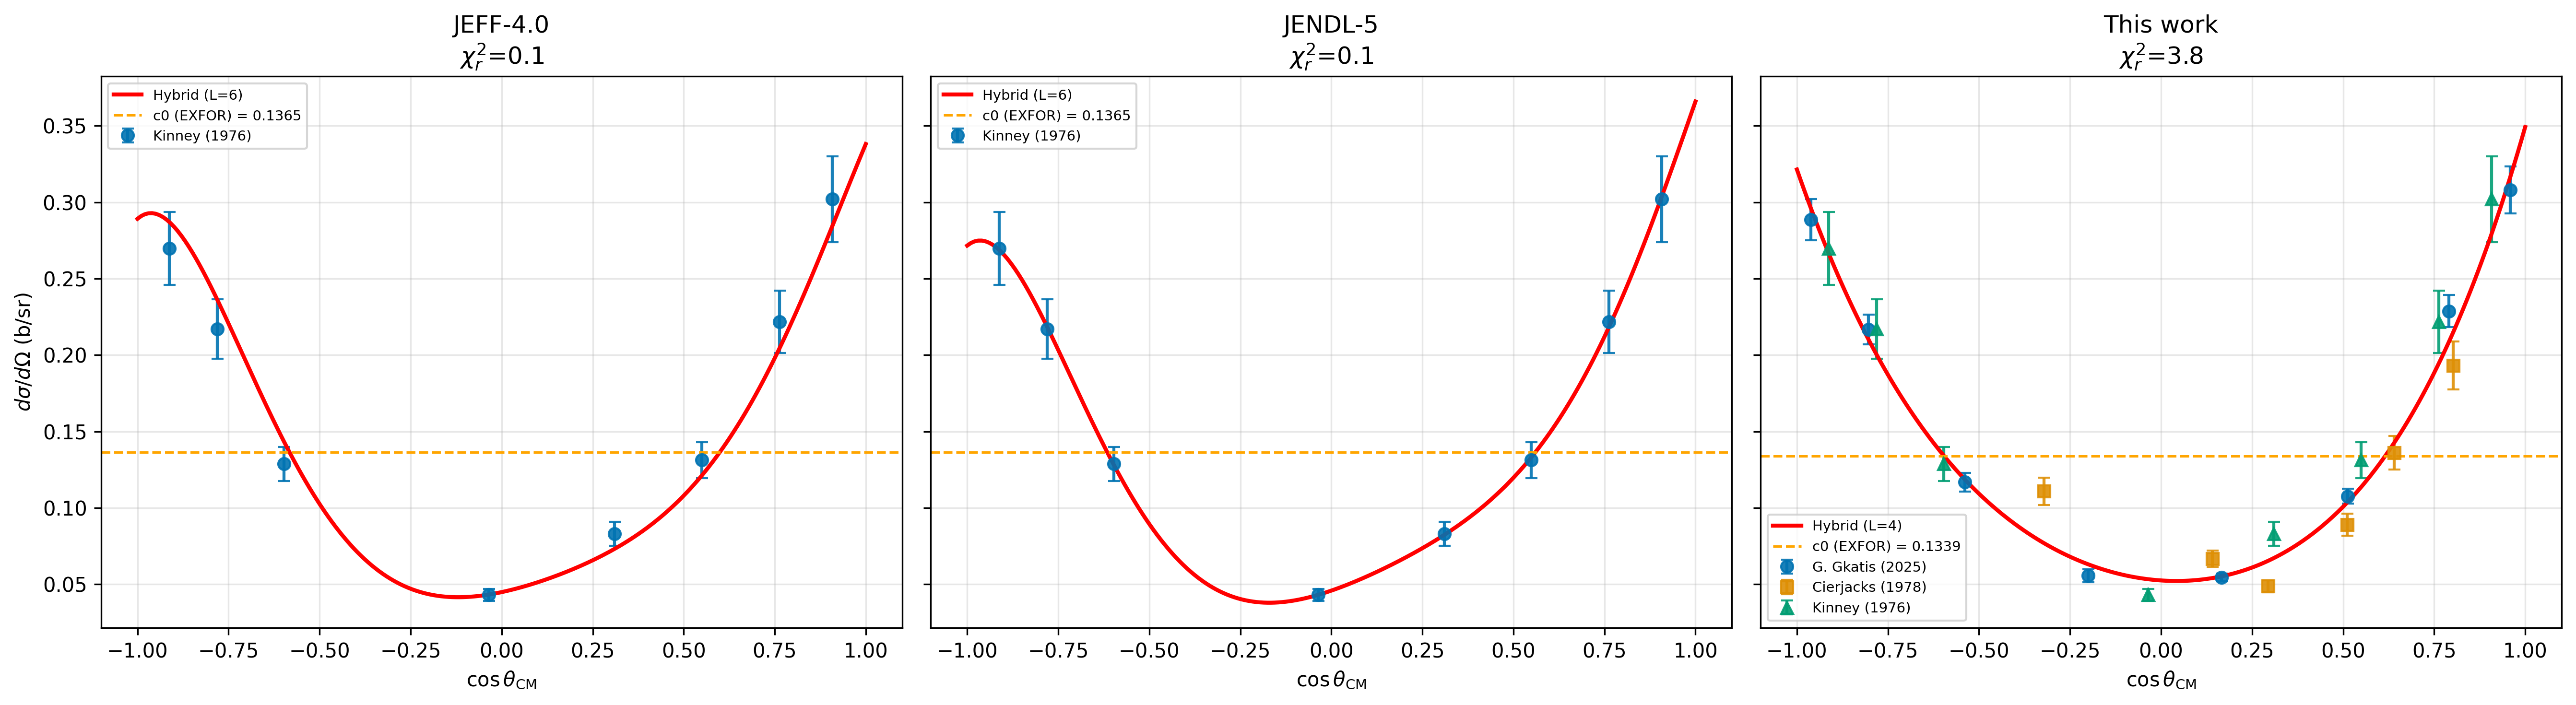

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

cases = [
    ("JEFF-4.0",   jeff_fit,  jeff_exfor,  jeff_exp_info),
    ("JENDL-5",    jendl_fit, jendl_exfor, jendl_exp_info),
    ("This work",  user_fit,  user_exfor,  user_exp_info),
]

mu_plot = np.linspace(-1, 1, 200)

for ax, (label, fit, df, exp_info) in zip(axes, cases):
    if df is not None and not df.empty:
        exp_ids = df['experiment_id'].unique()
        for i, eid in enumerate(exp_ids):
            m = df['experiment_id'] == eid
            info = next((e for e in exp_info
                         if f"{e.get('entry','')}/{e.get('subentry','')}" == eid), {})
            ax.errorbar(df.loc[m, 'mu'], df.loc[m, 'value'], yerr=df.loc[m, 'unc'],
                        fmt=EXFOR_MARKERS[i % len(EXFOR_MARKERS)],
                        color=KIKA_COLORS[i % len(KIKA_COLORS)],
                        label=f"{info.get('author', eid)} ({info.get('year','?')})",
                        capsize=3, markersize=6, alpha=0.9)
    if fit is not None:
        y_fit = legval(mu_plot, fit['hybrid_coeffs'])
        ax.plot(mu_plot, y_fit, 'r-', lw=2, label=f"Hybrid (L={fit['degree']})")
        ax.axhline(fit['c0'], color='orange', ls='--', lw=1.2,
                   label=f"c0 (EXFOR) = {fit['c0']:.4f}")
    ax.set_xlabel(r'$\cos\theta_{\rm CM}$')
    ax.set_title(f'{label}\n$\\chi^2_r$={fit["fit_info"]["chi2_red"]:.1f}' if fit else label)
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel(r'$d\sigma/d\Omega$ (b/sr)')
plt.tight_layout()
save_figure_structured(fig, 'diagnostic', filename='exfor_fit_verification')
plt.show()

## 10. Per-Library Uncertainty Plots

  Saved: /share_snc/snc/JuanMonleon/DA_Figures/E_1.17_MeV/JEFF_4.0/individual_legendre_bands_log.png


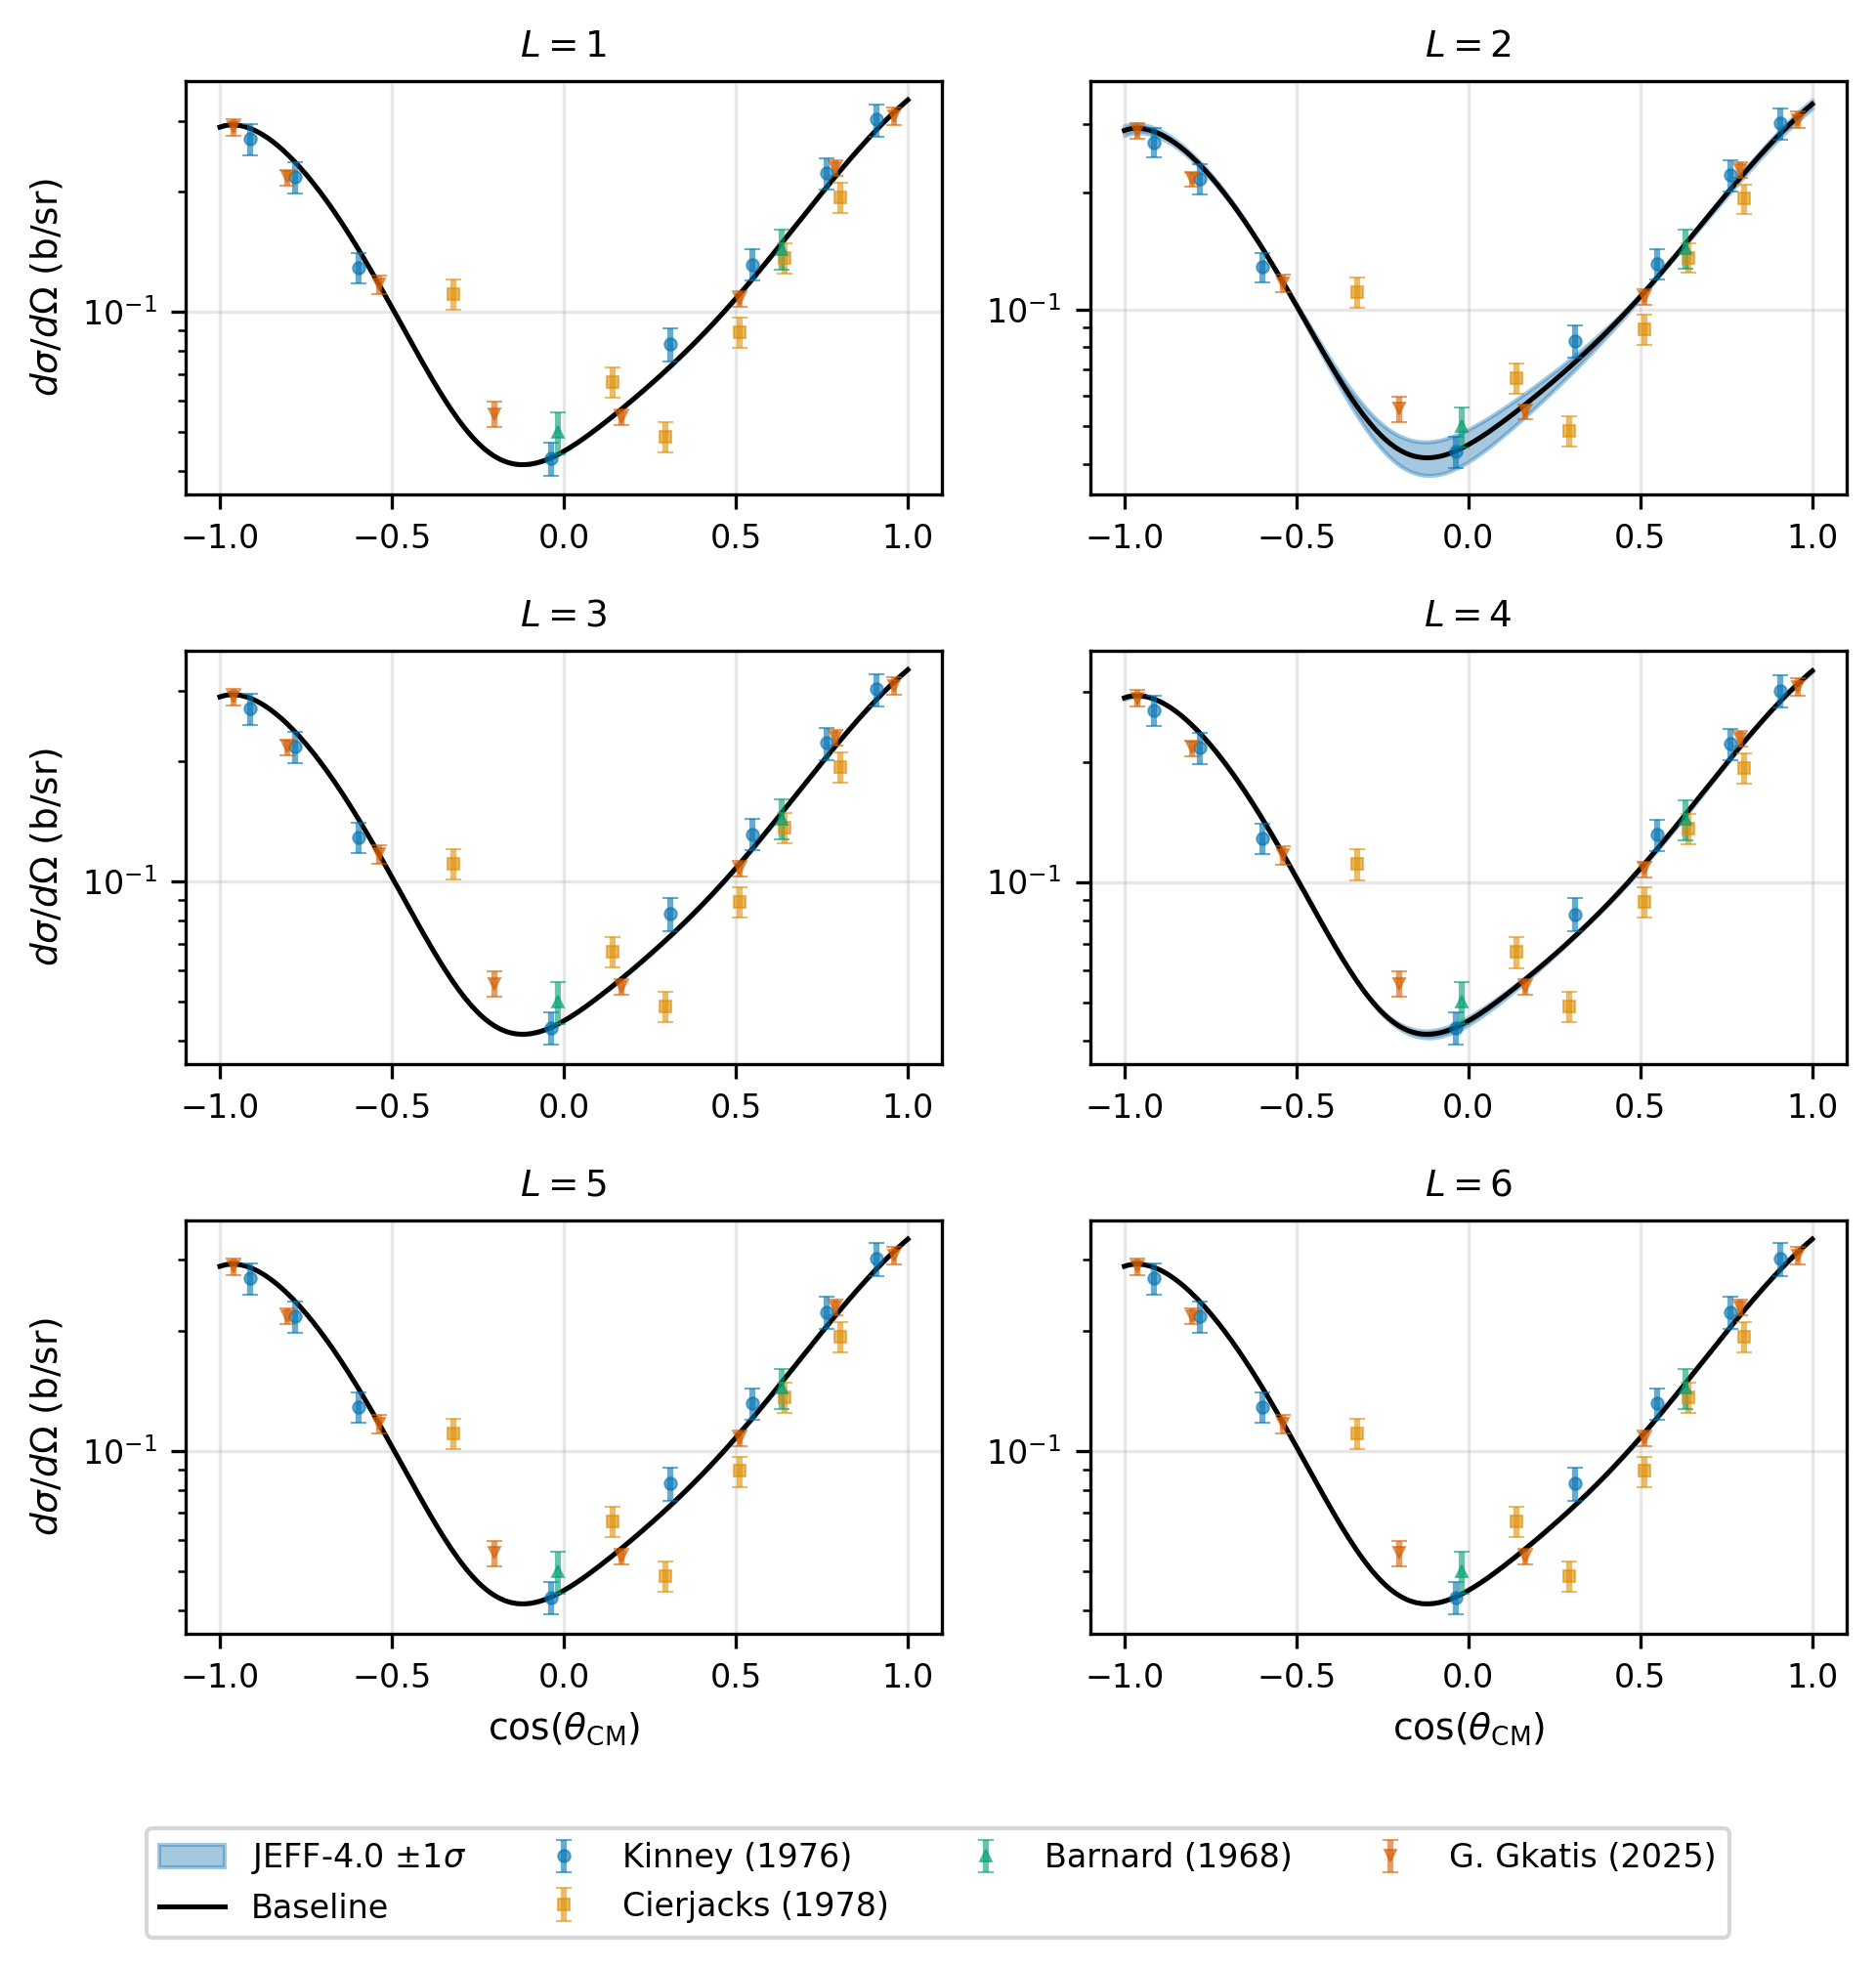

  Saved: /share_snc/snc/JuanMonleon/DA_Figures/E_1.17_MeV/JEFF_4.0/individual_legendre_bands_linear.png
  Saved: /share_snc/snc/JuanMonleon/DA_Figures/E_1.17_MeV/JENDL_5/individual_legendre_bands_log.png


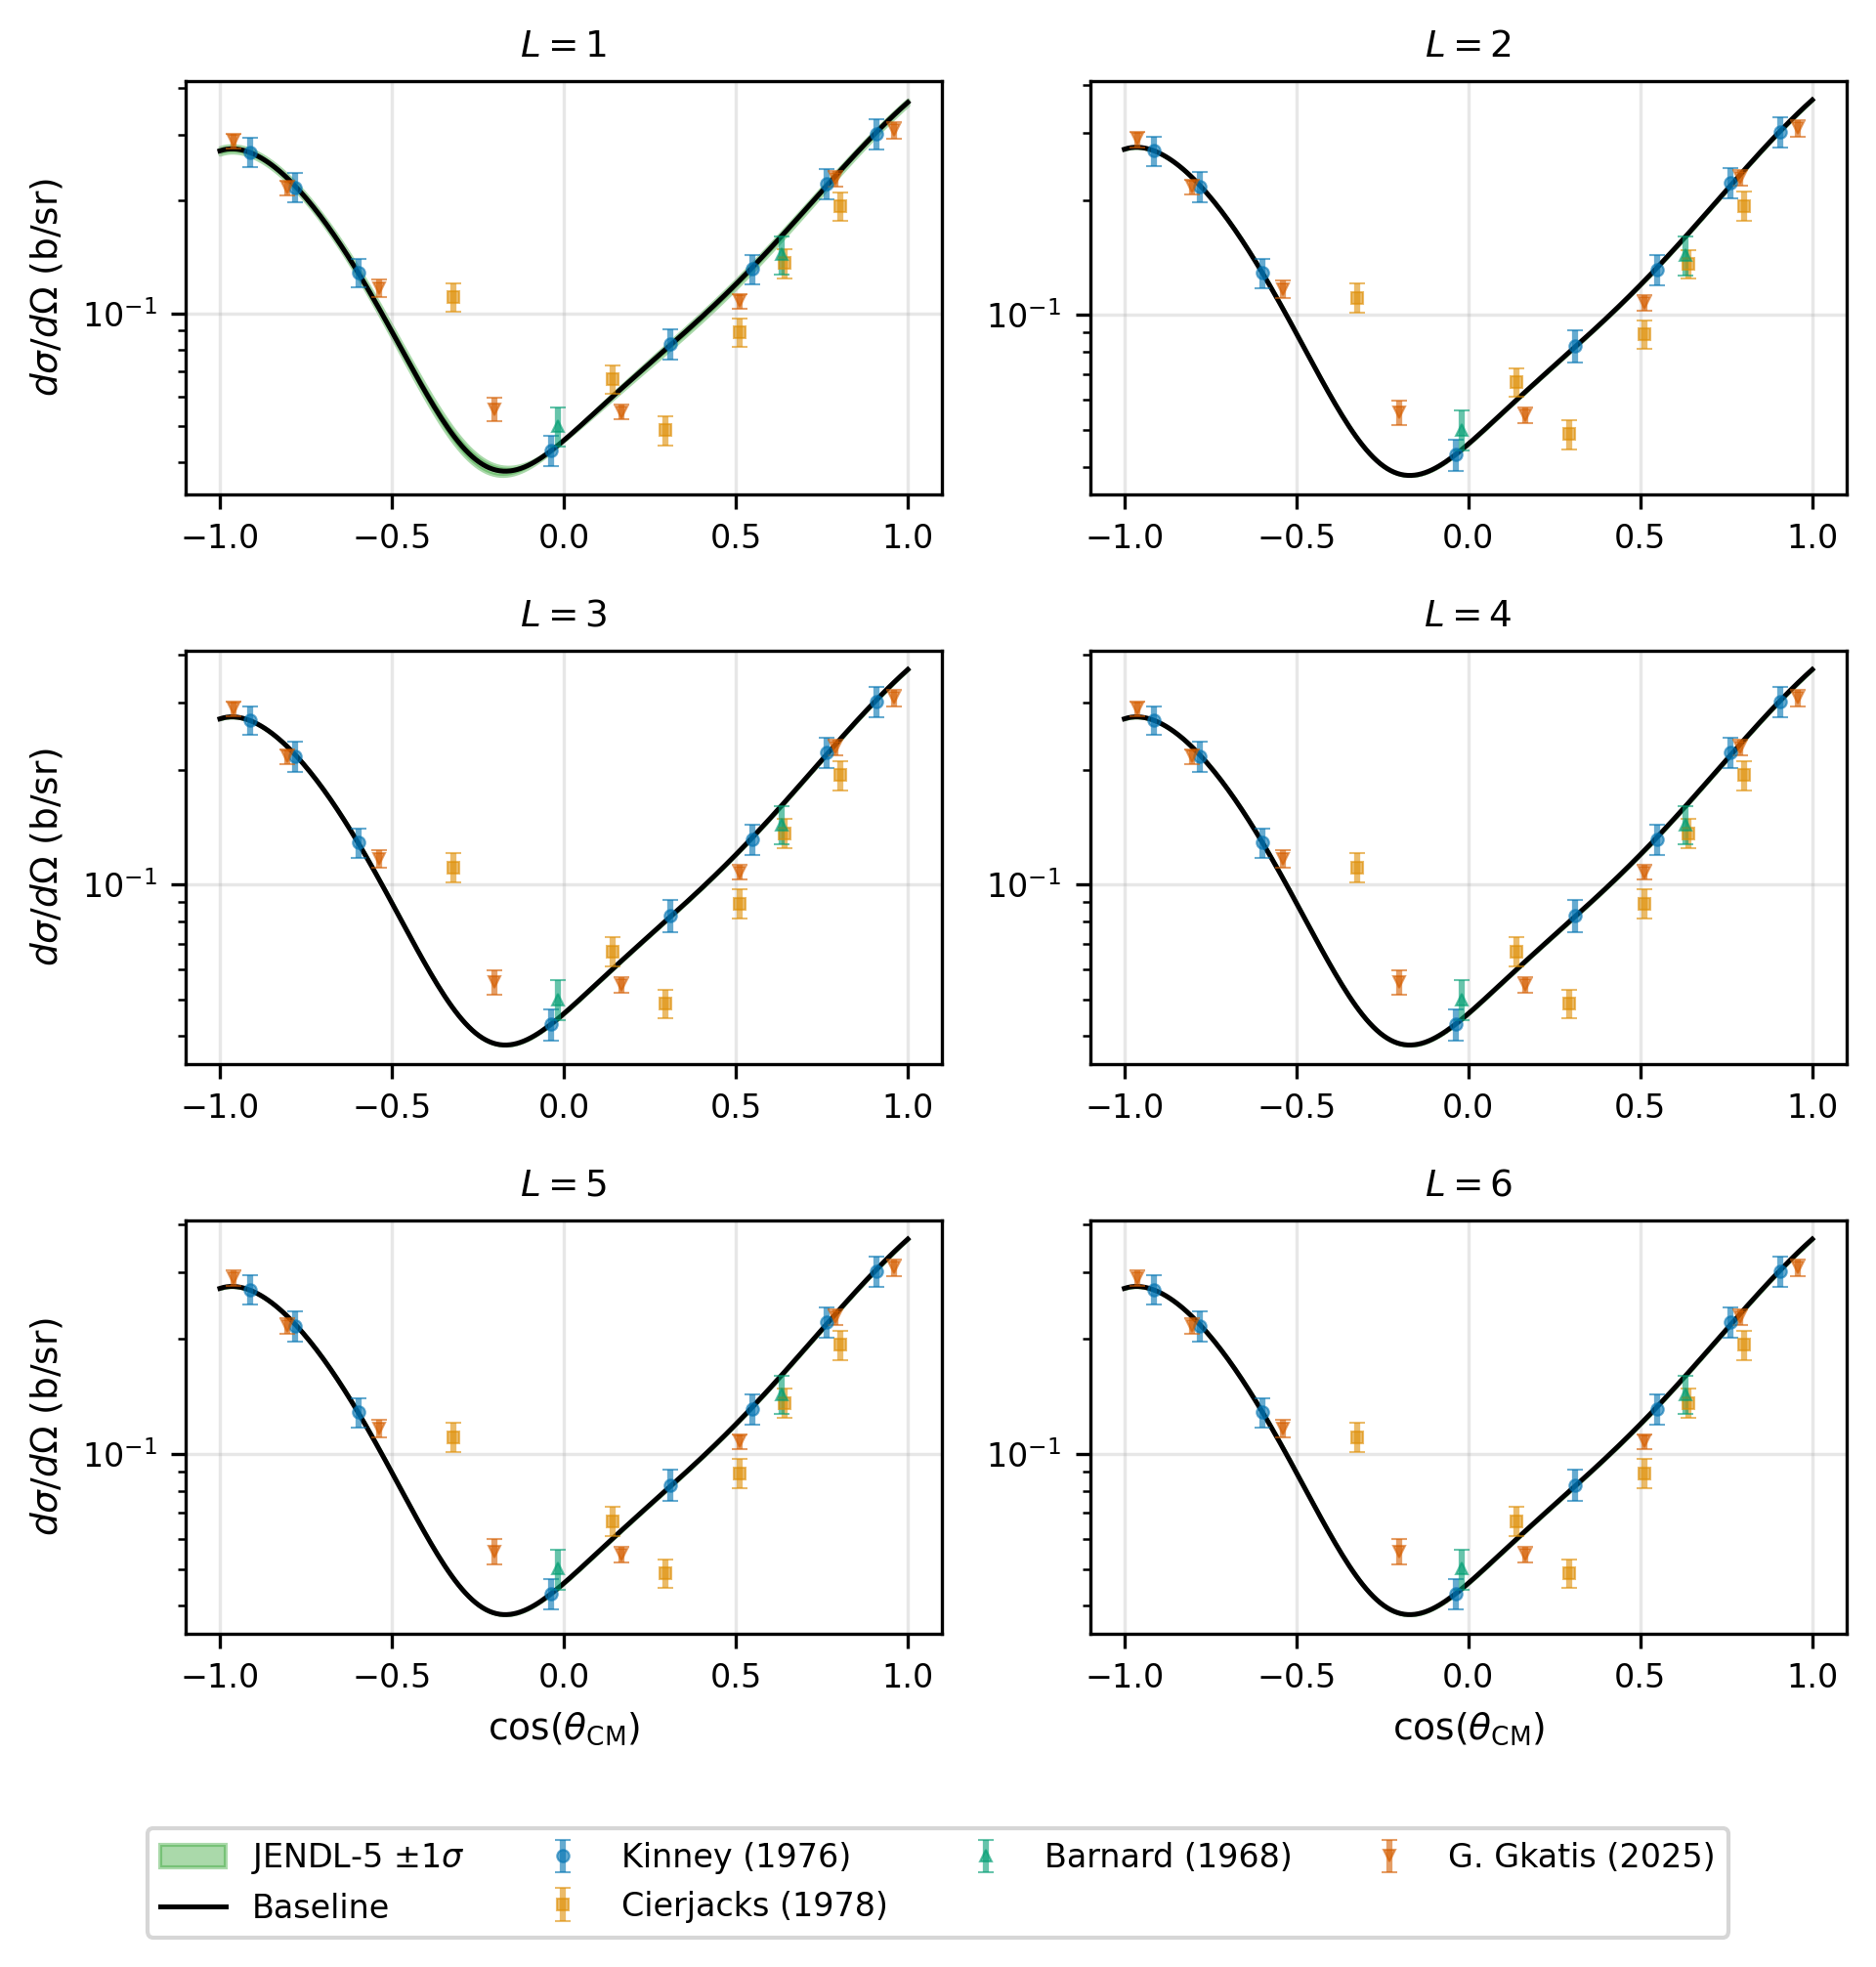

  Saved: /share_snc/snc/JuanMonleon/DA_Figures/E_1.17_MeV/JENDL_5/individual_legendre_bands_linear.png
  Saved: /share_snc/snc/JuanMonleon/DA_Figures/E_1.17_MeV/This_work/individual_legendre_bands_log.png


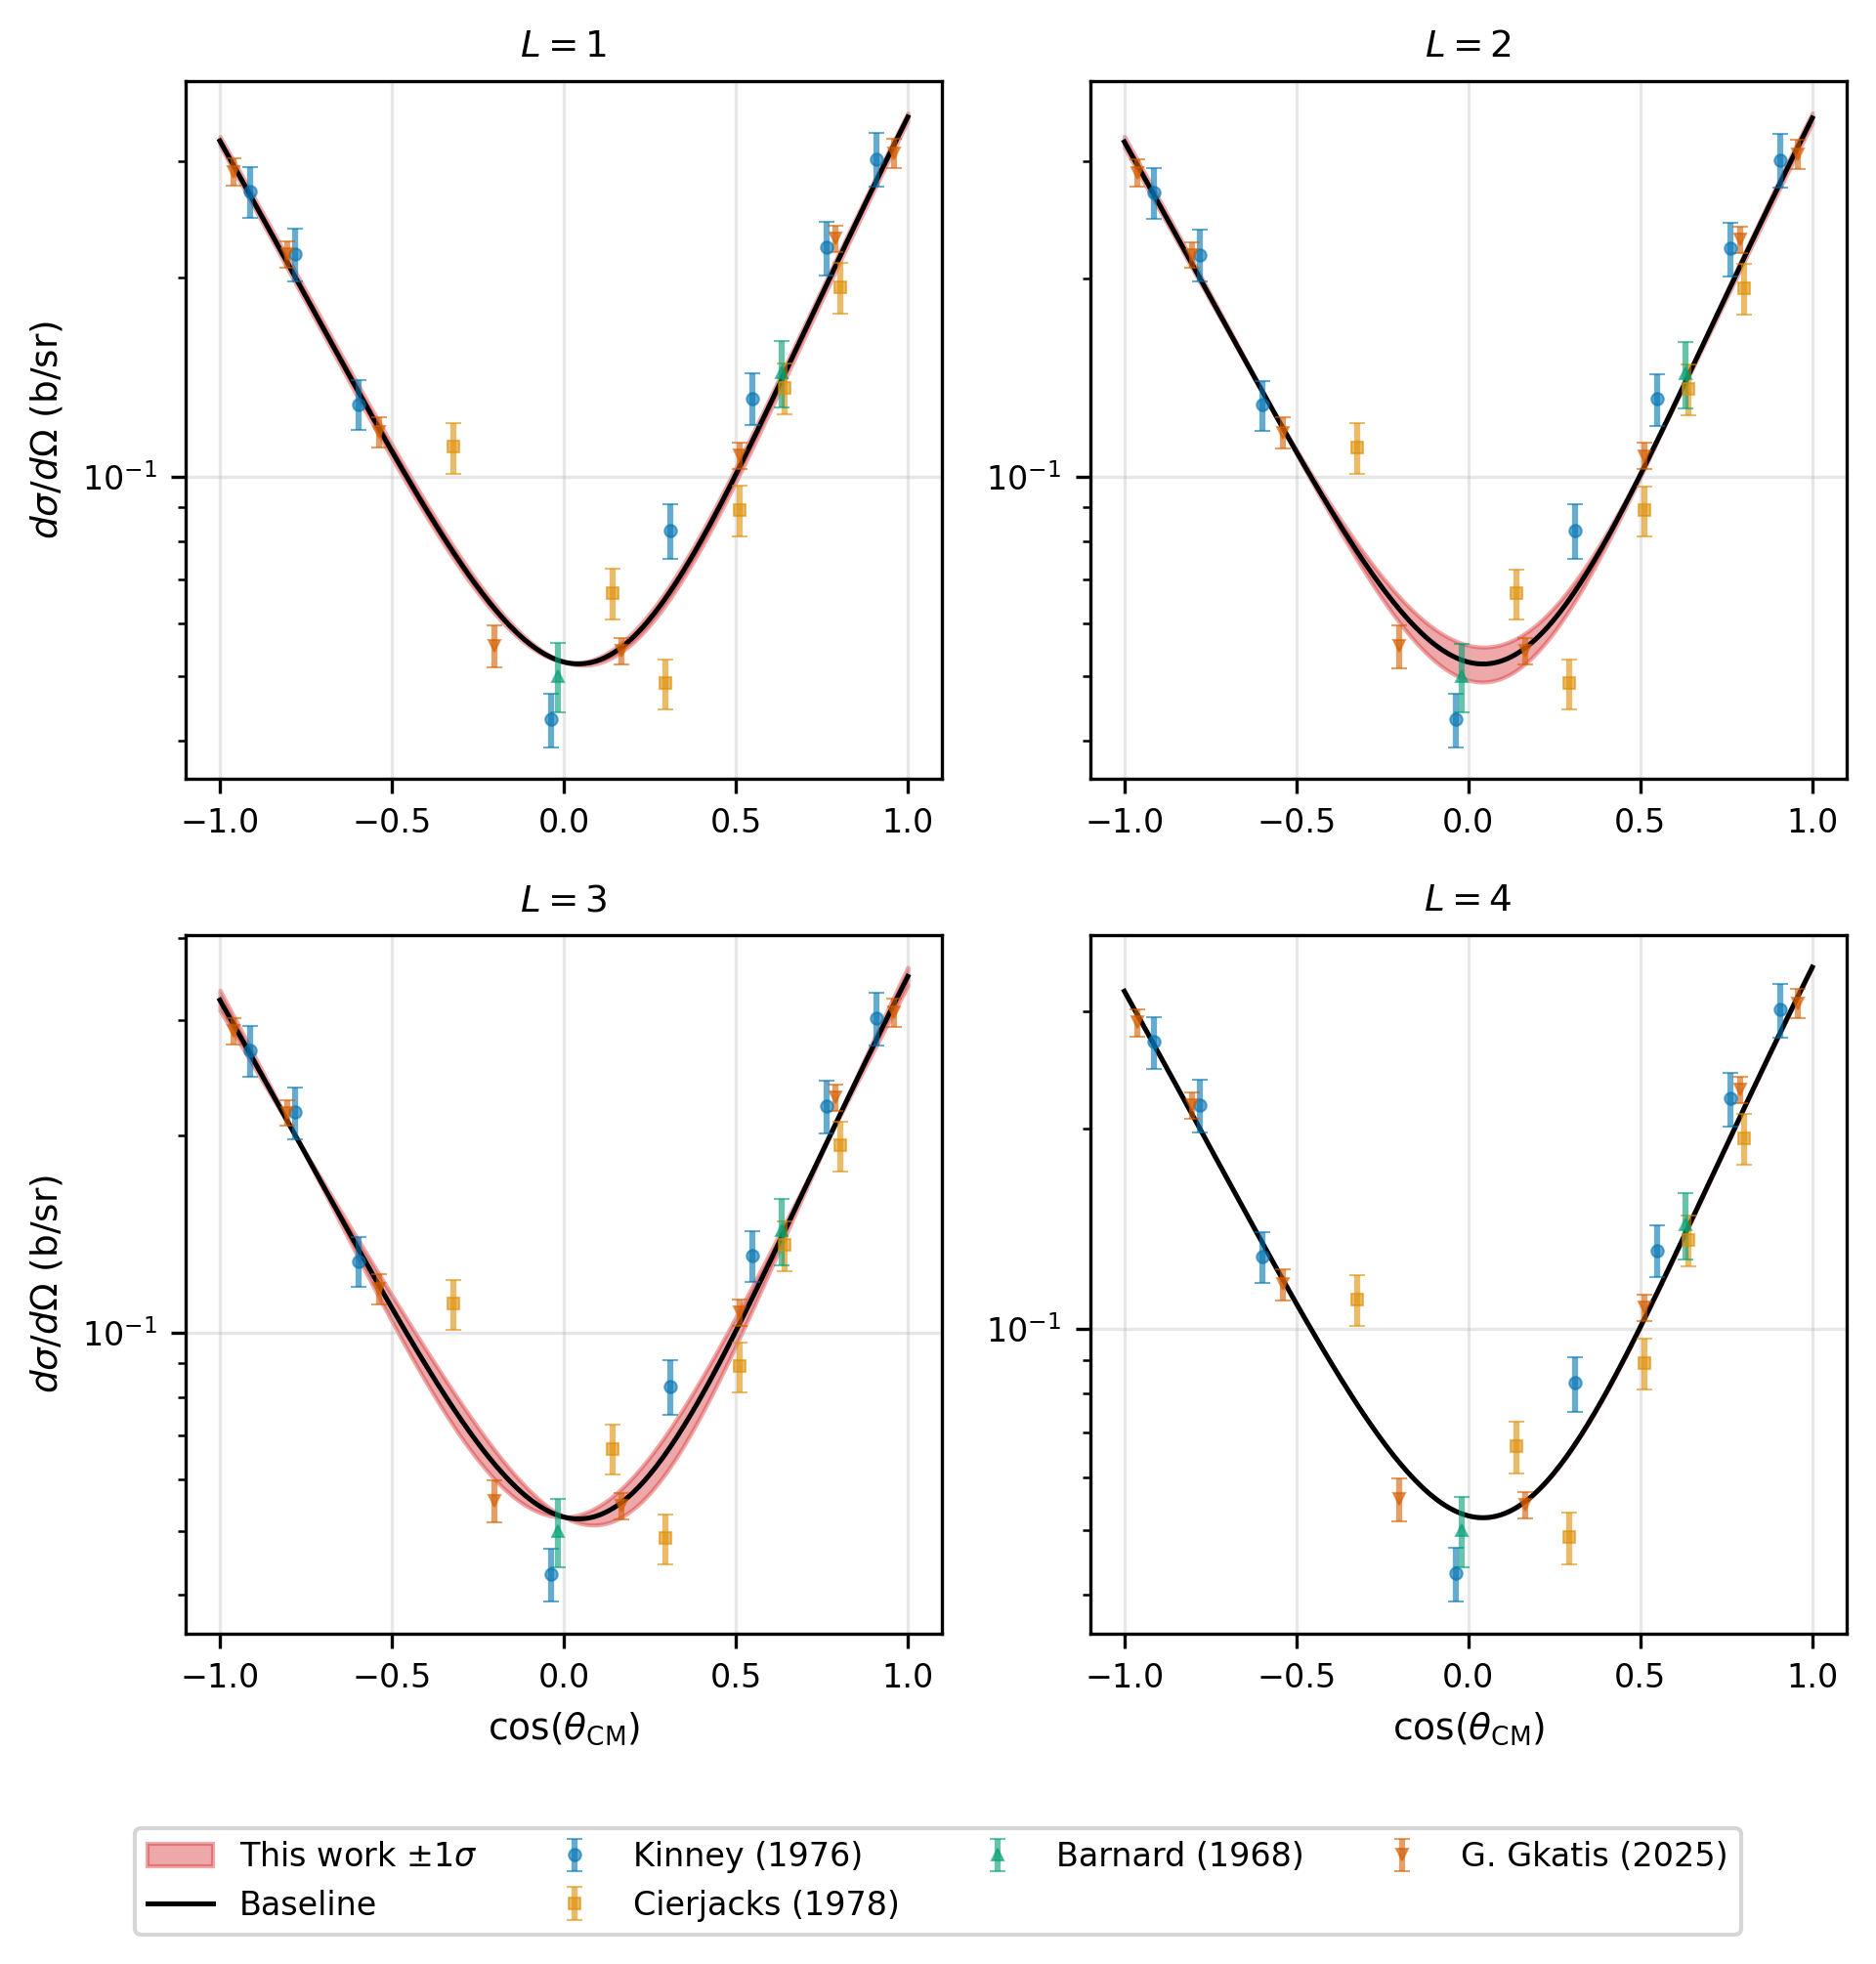

  Saved: /share_snc/snc/JuanMonleon/DA_Figures/E_1.17_MeV/This_work/individual_legendre_bands_linear.png


In [29]:
# --- Individual Legendre bands (2-column grid) ---
for key in case_keys:
    r = all_results[key]
    cd = case_exfor_data[key]
    color = CASE_COLORS[key]

    for yscale in ['log', 'linear']:
        fig = plot_individual_grid(r, cd['exfor_all'], cd['exp_info_all'], key,
                                   yscale=yscale, band_color=color)
        save_figure_structured(fig, 'individual', library=key,
                               filename='individual_legendre_bands', yscale=yscale)
        if yscale == PLOT_YSCALE:
            plt.show()
        else:
            plt.close(fig)

  Saved: /share_snc/snc/JuanMonleon/DA_Figures/E_1.17_MeV/JEFF_4.0/cumulative_legendre_bands_log.png


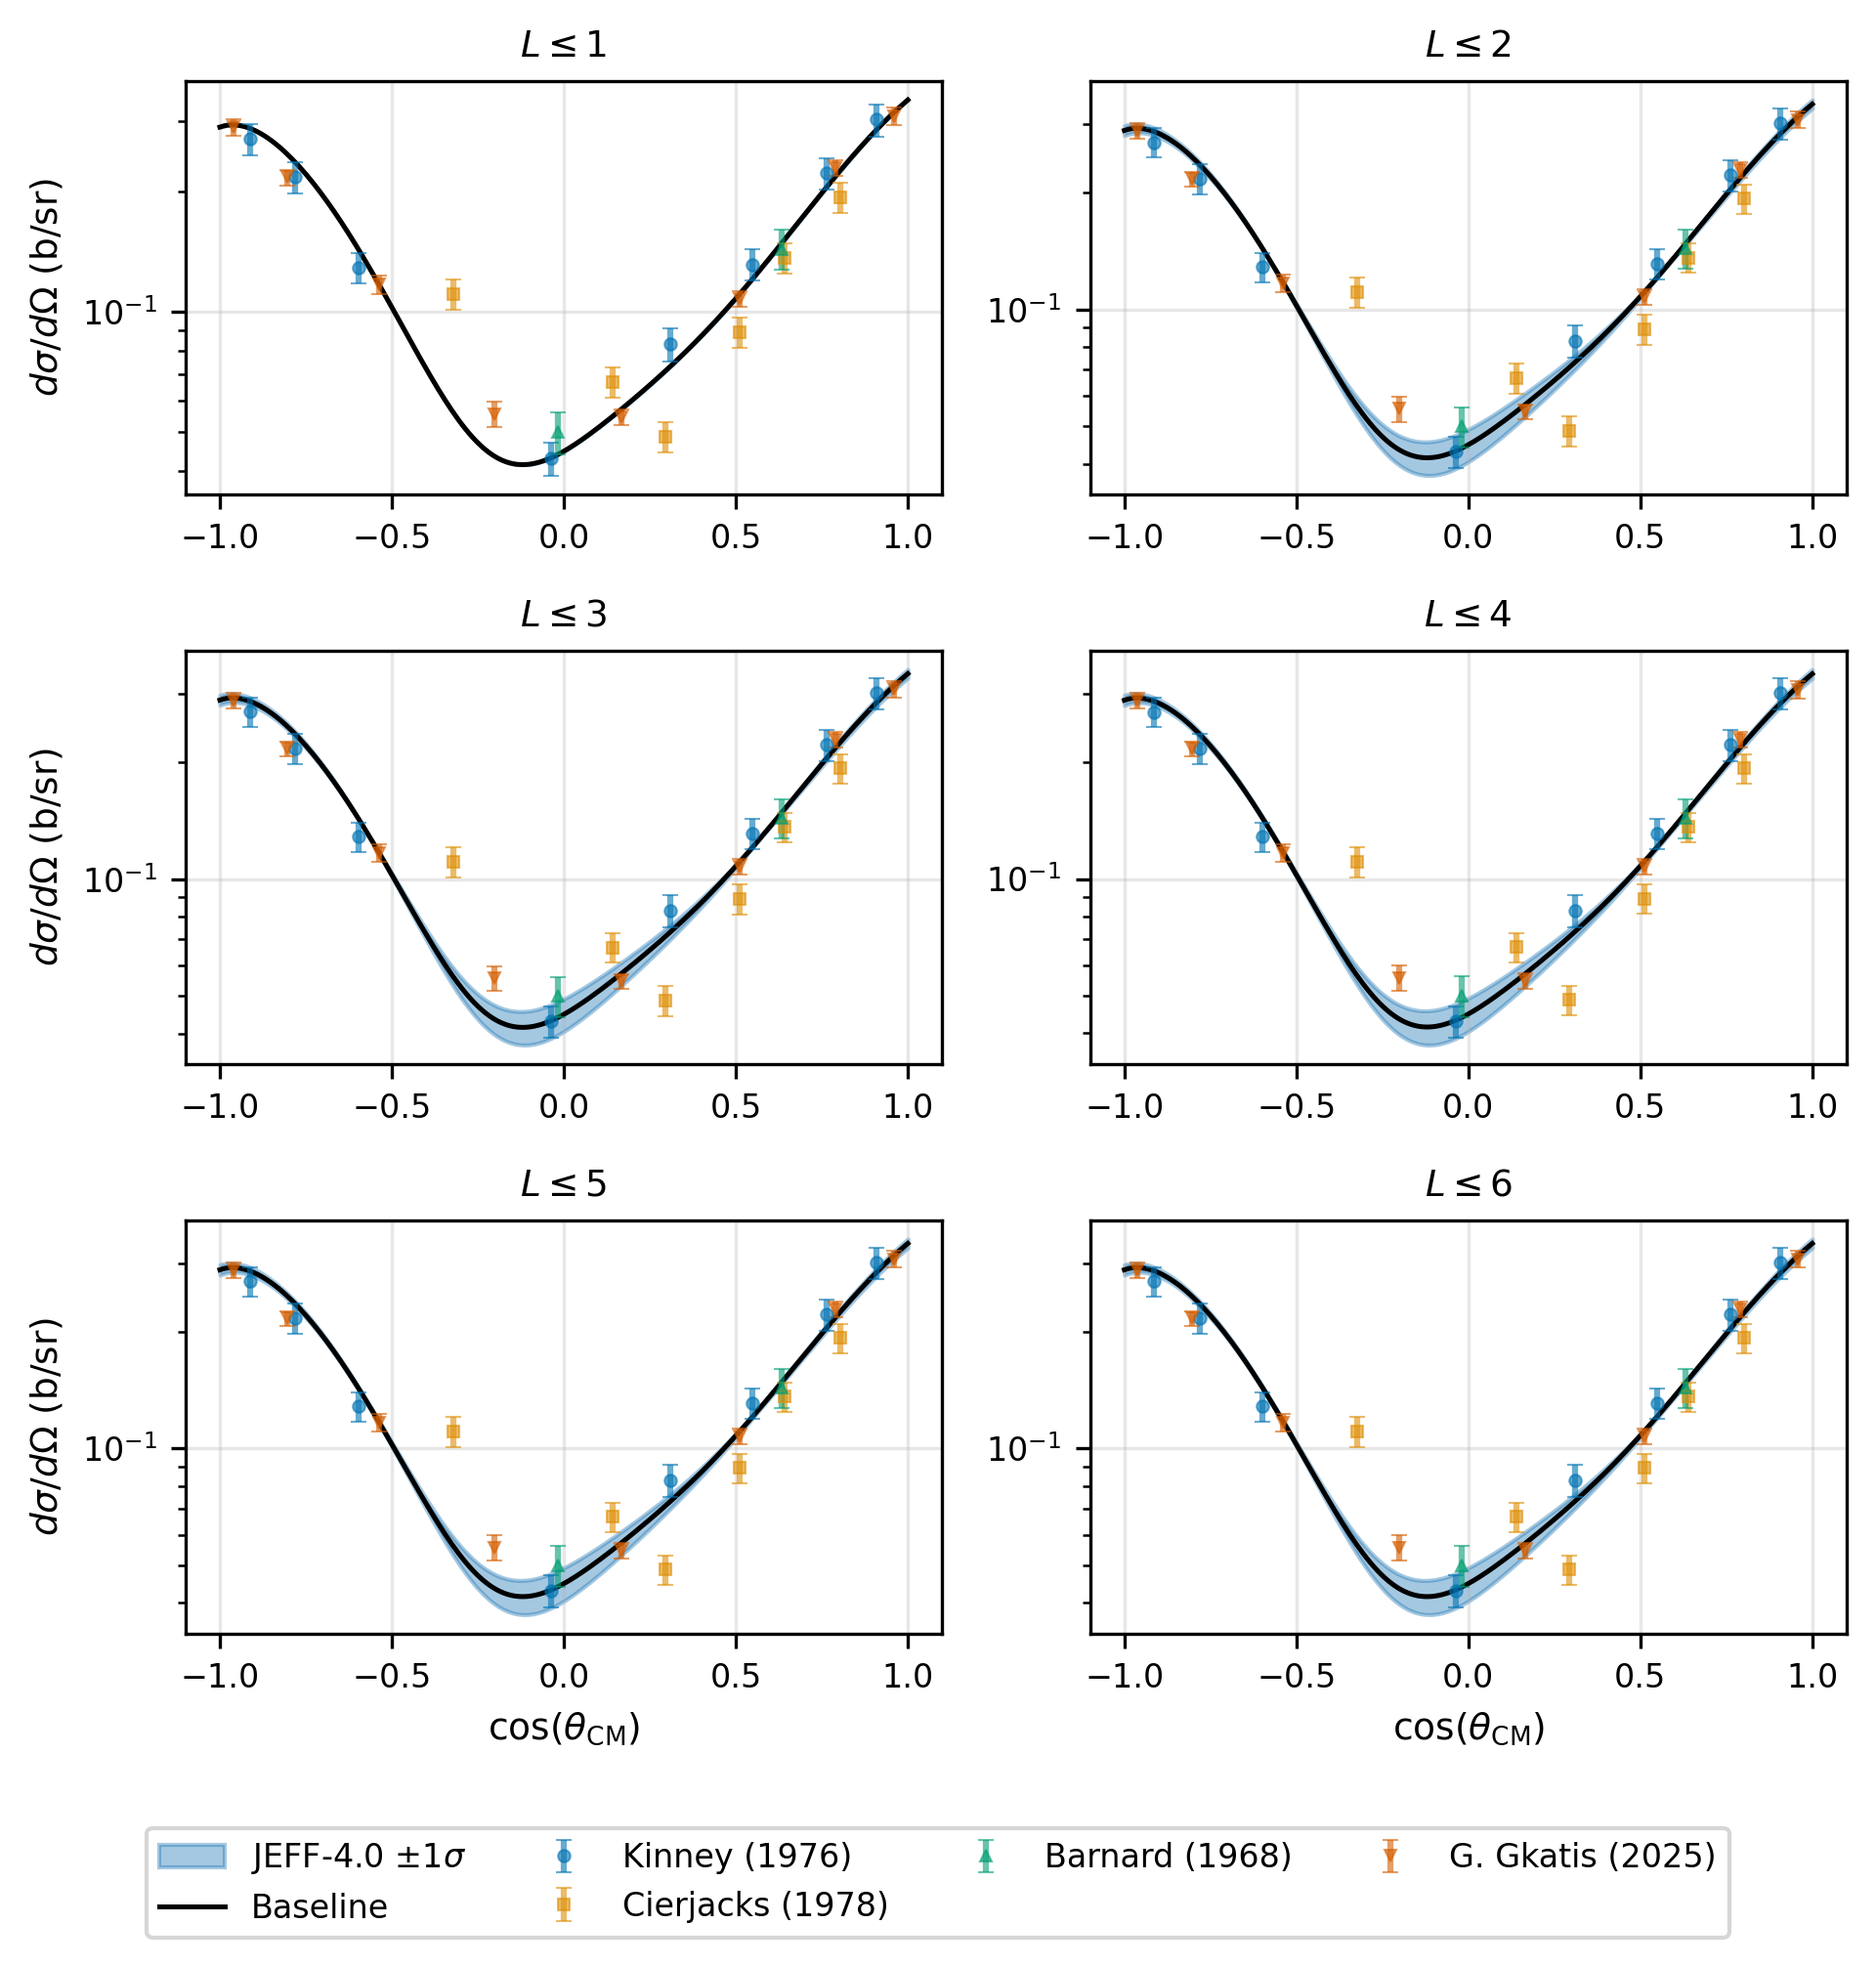

  Saved: /share_snc/snc/JuanMonleon/DA_Figures/E_1.17_MeV/JEFF_4.0/cumulative_legendre_bands_linear.png
  Saved: /share_snc/snc/JuanMonleon/DA_Figures/E_1.17_MeV/JENDL_5/cumulative_legendre_bands_log.png


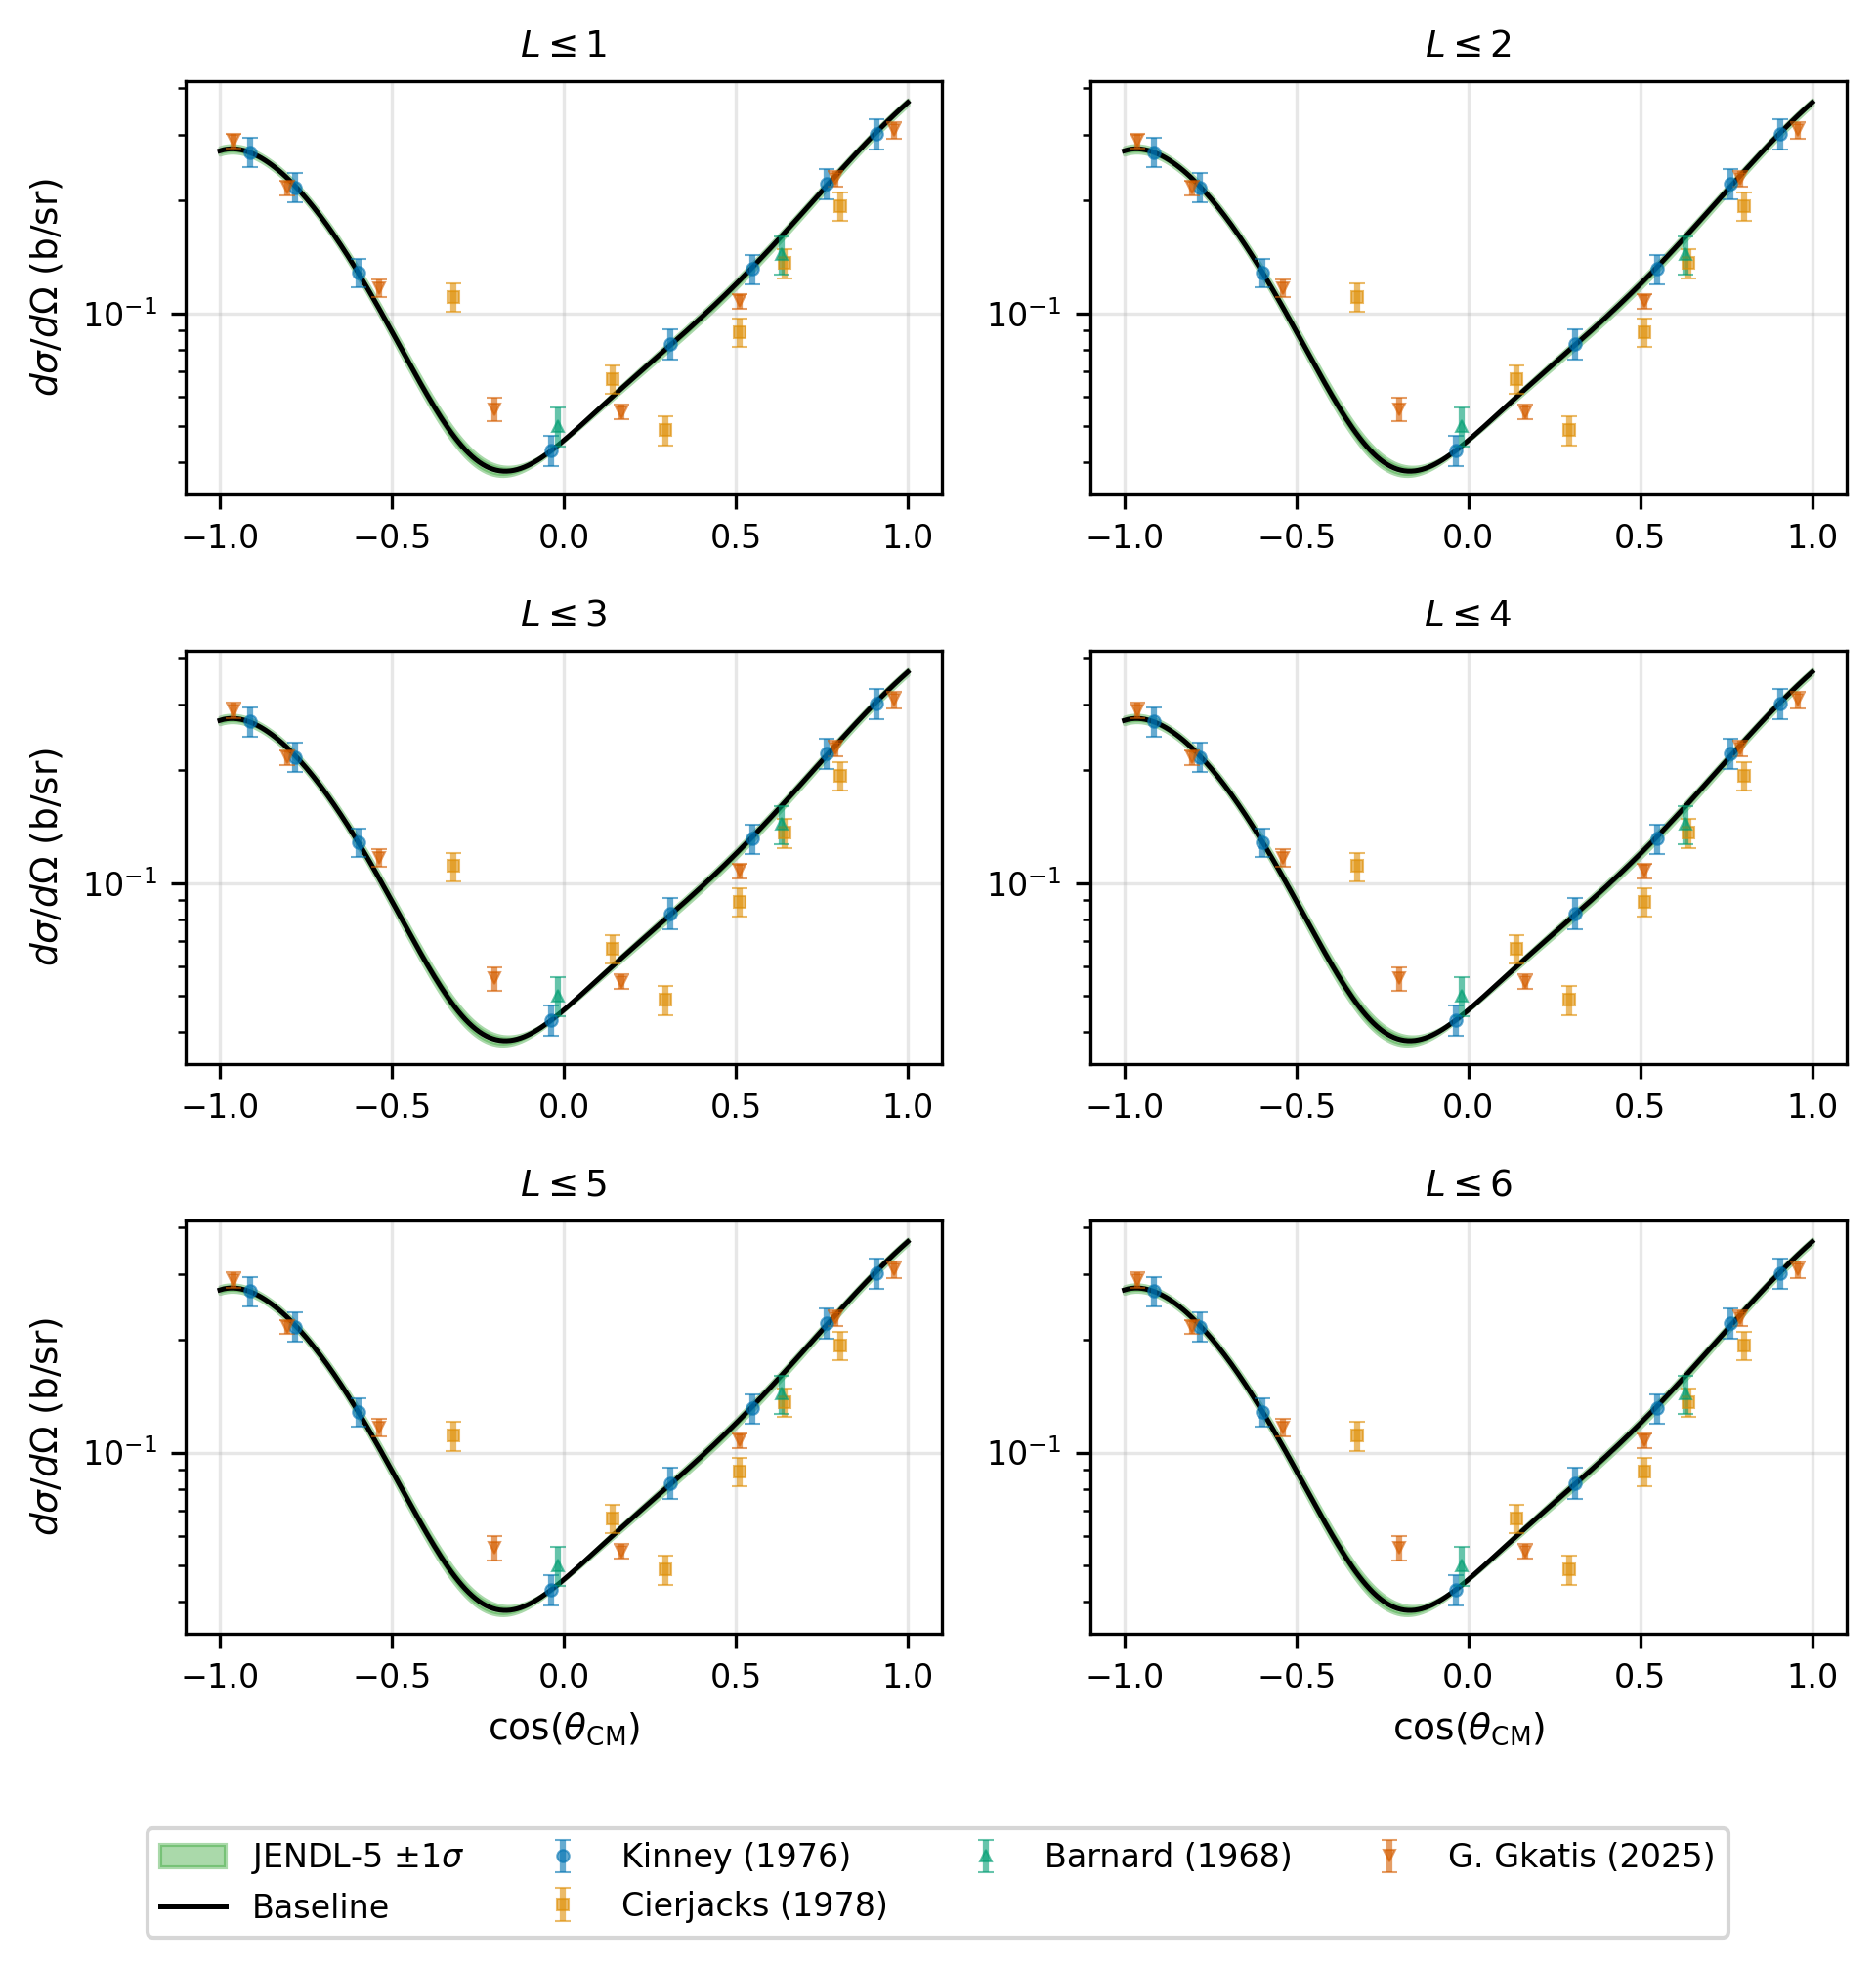

  Saved: /share_snc/snc/JuanMonleon/DA_Figures/E_1.17_MeV/JENDL_5/cumulative_legendre_bands_linear.png
  Saved: /share_snc/snc/JuanMonleon/DA_Figures/E_1.17_MeV/This_work/cumulative_legendre_bands_log.png


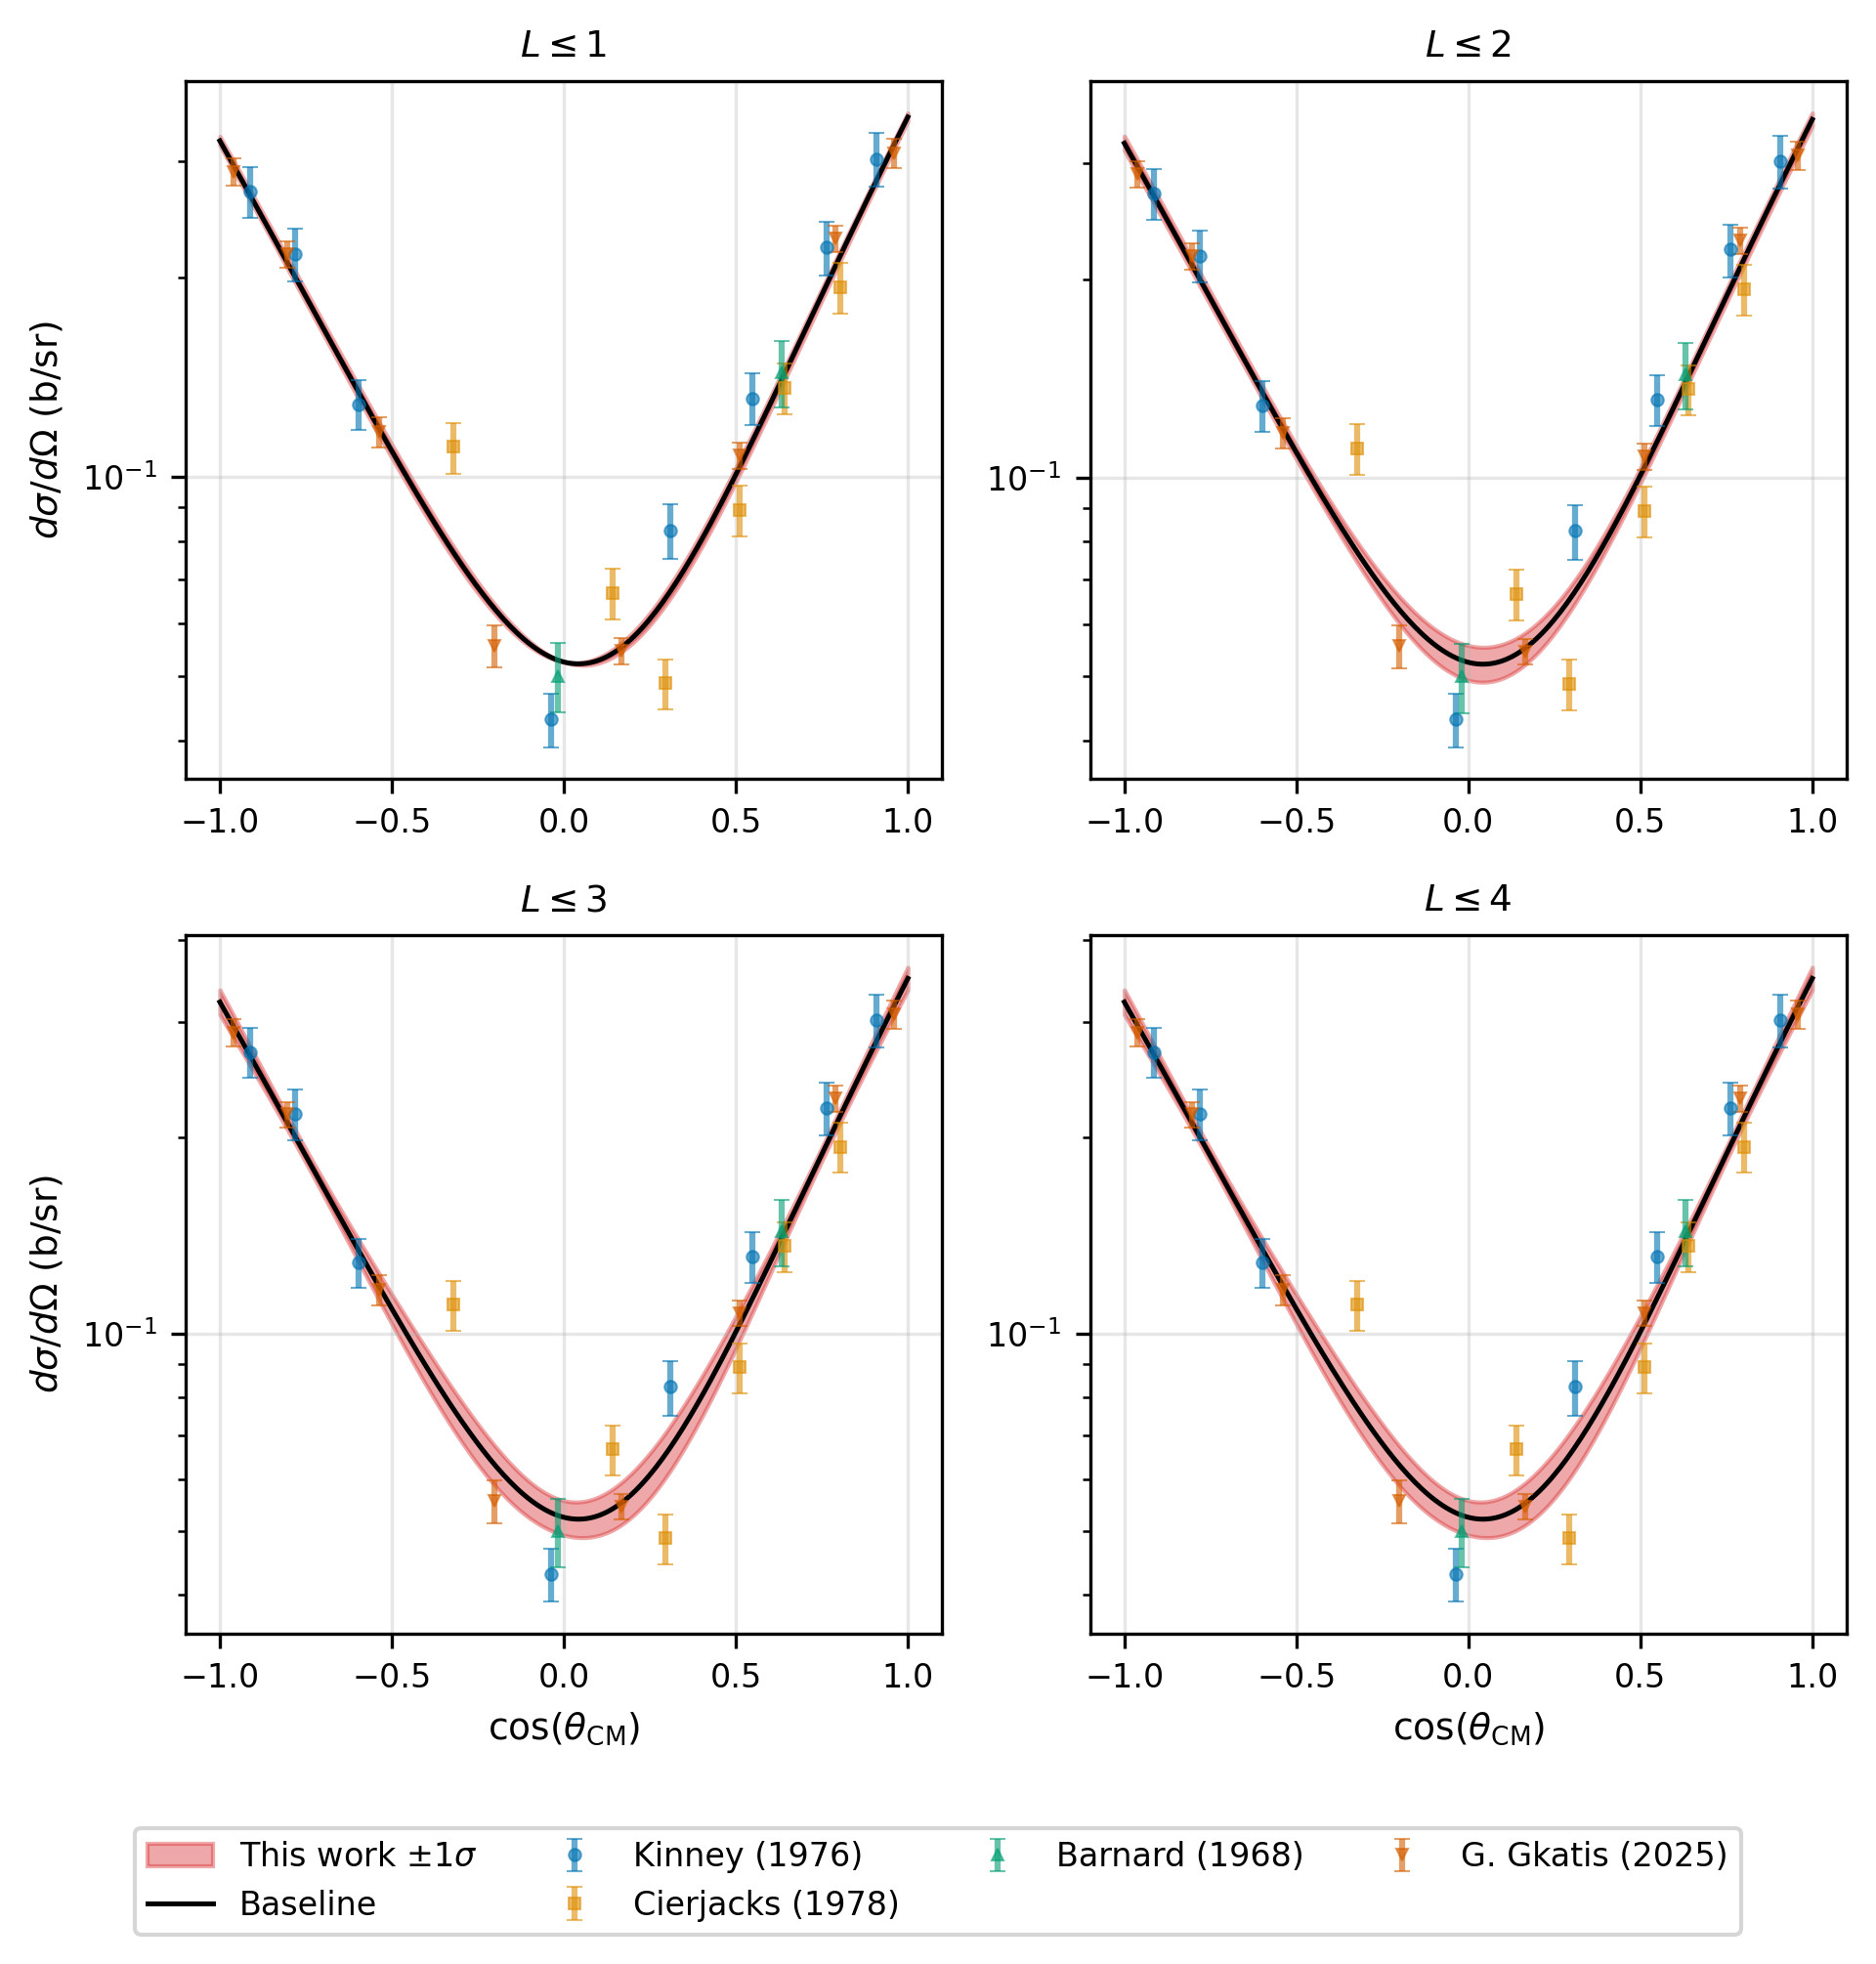

  Saved: /share_snc/snc/JuanMonleon/DA_Figures/E_1.17_MeV/This_work/cumulative_legendre_bands_linear.png


In [30]:
# --- Cumulative Legendre bands (2-column grid) ---
for key in case_keys:
    r = all_results[key]
    cd = case_exfor_data[key]
    color = CASE_COLORS[key]

    for yscale in ['log', 'linear']:
        fig = plot_cumulative_grid(r, cd['exfor_all'], cd['exp_info_all'], key,
                                    yscale=yscale, band_color=color)
        save_figure_structured(fig, 'cumulative', library=key,
                               filename='cumulative_legendre_bands', yscale=yscale)
        if yscale == PLOT_YSCALE:
            plt.show()
        else:
            plt.close(fig)

  Saved: /share_snc/snc/JuanMonleon/DA_Figures/E_1.17_MeV/JEFF_4.0/summary_combined_log.png


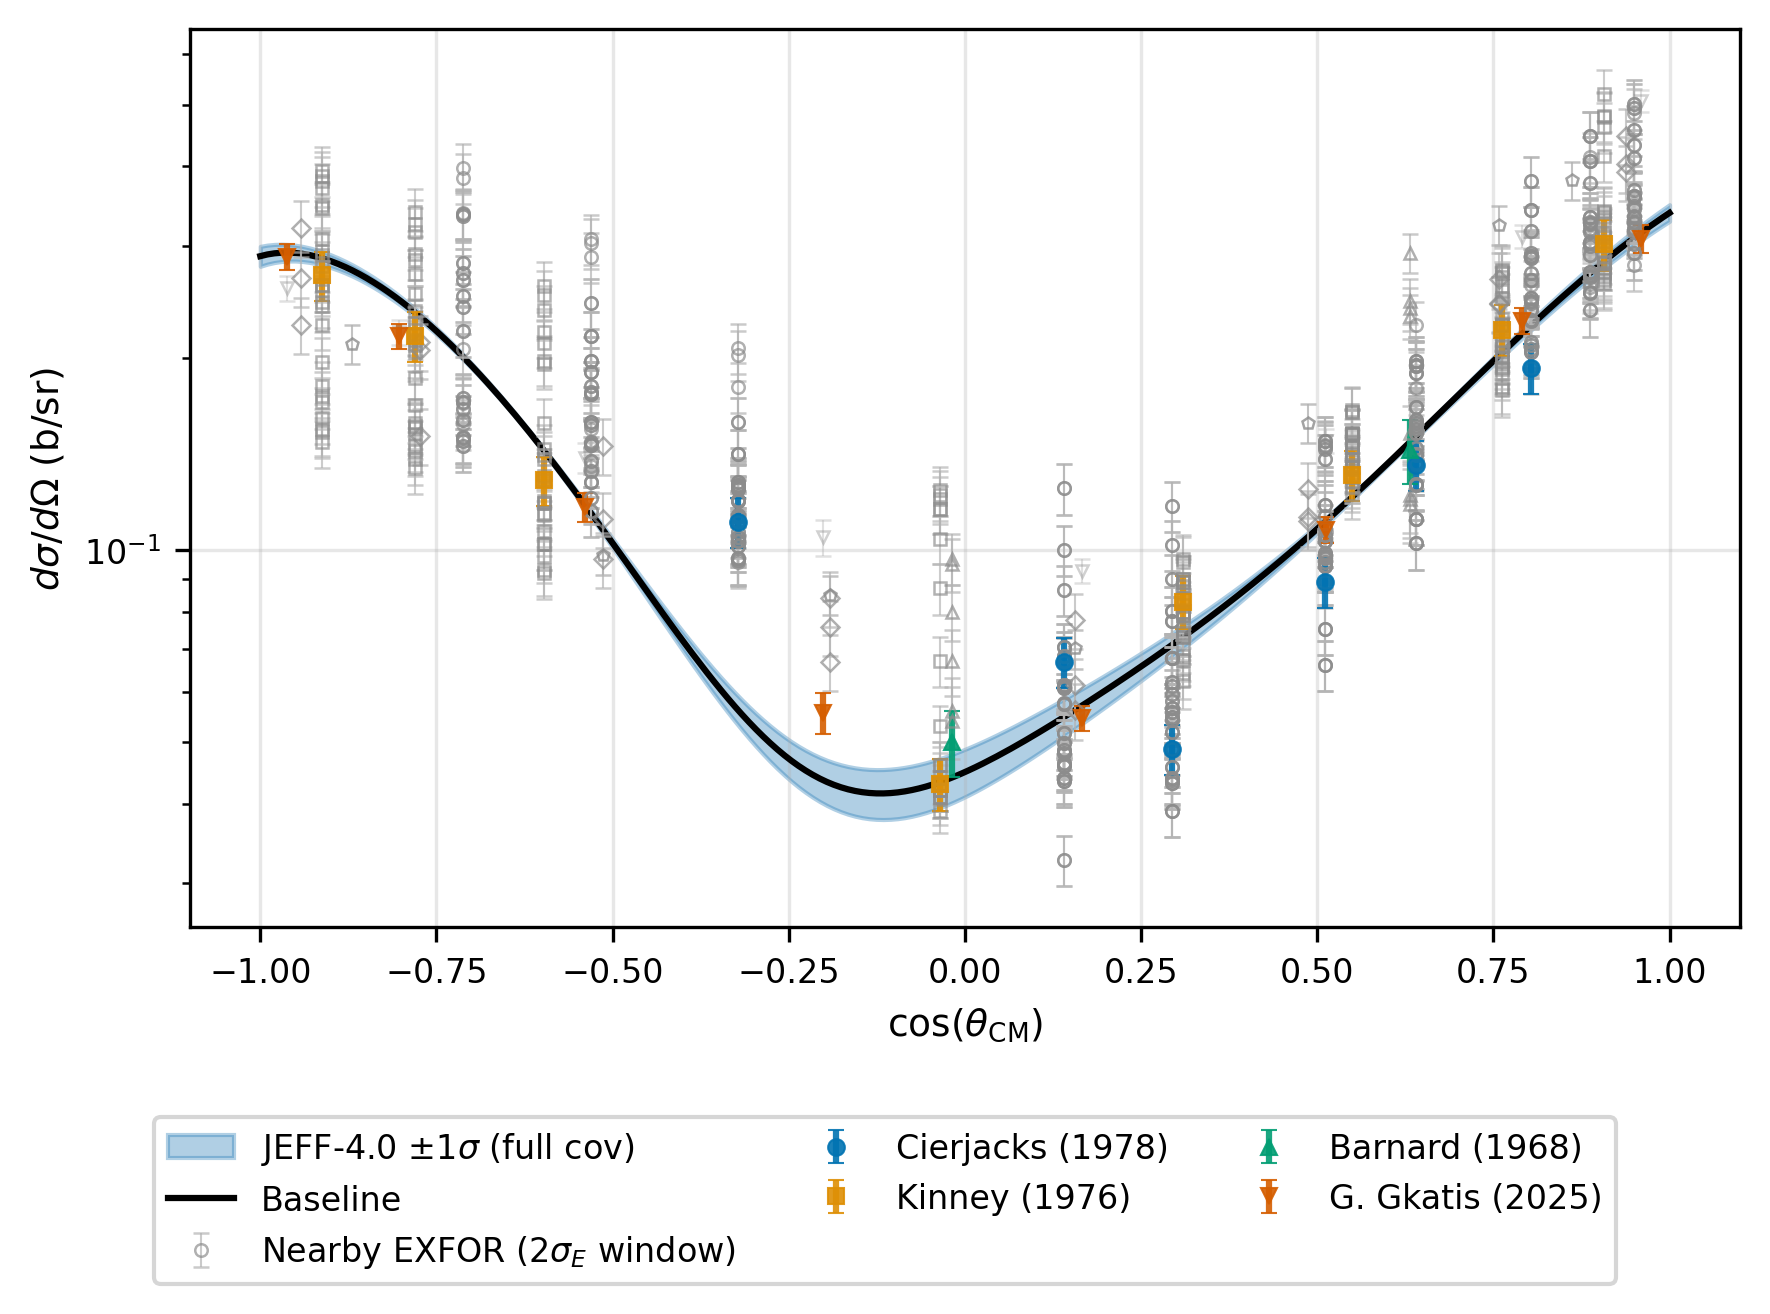

  Saved: /share_snc/snc/JuanMonleon/DA_Figures/E_1.17_MeV/JEFF_4.0/summary_combined_linear.png
  Saved: /share_snc/snc/JuanMonleon/DA_Figures/E_1.17_MeV/JENDL_5/summary_combined_log.png


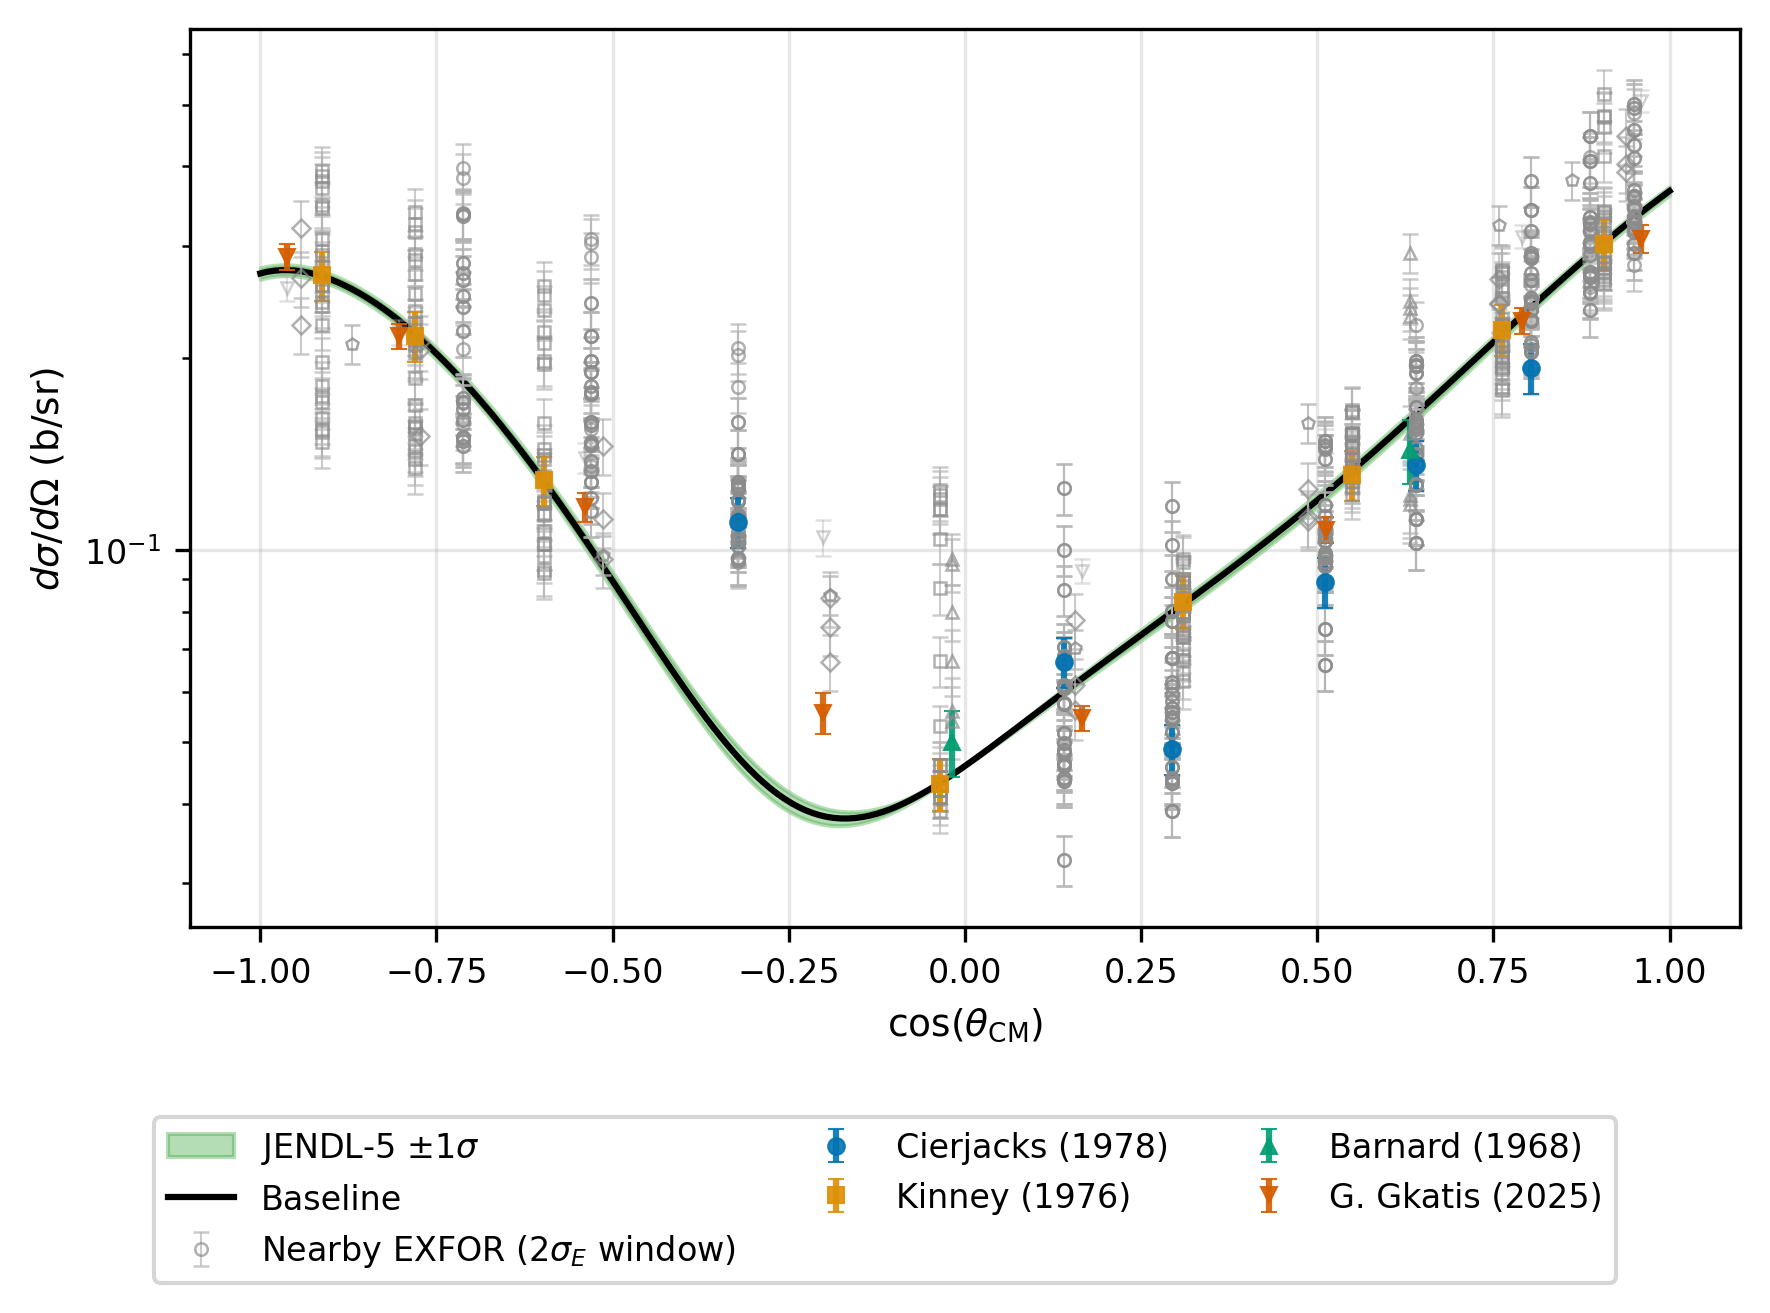

  Saved: /share_snc/snc/JuanMonleon/DA_Figures/E_1.17_MeV/JENDL_5/summary_combined_linear.png
  Saved: /share_snc/snc/JuanMonleon/DA_Figures/E_1.17_MeV/This_work/summary_combined_log.png


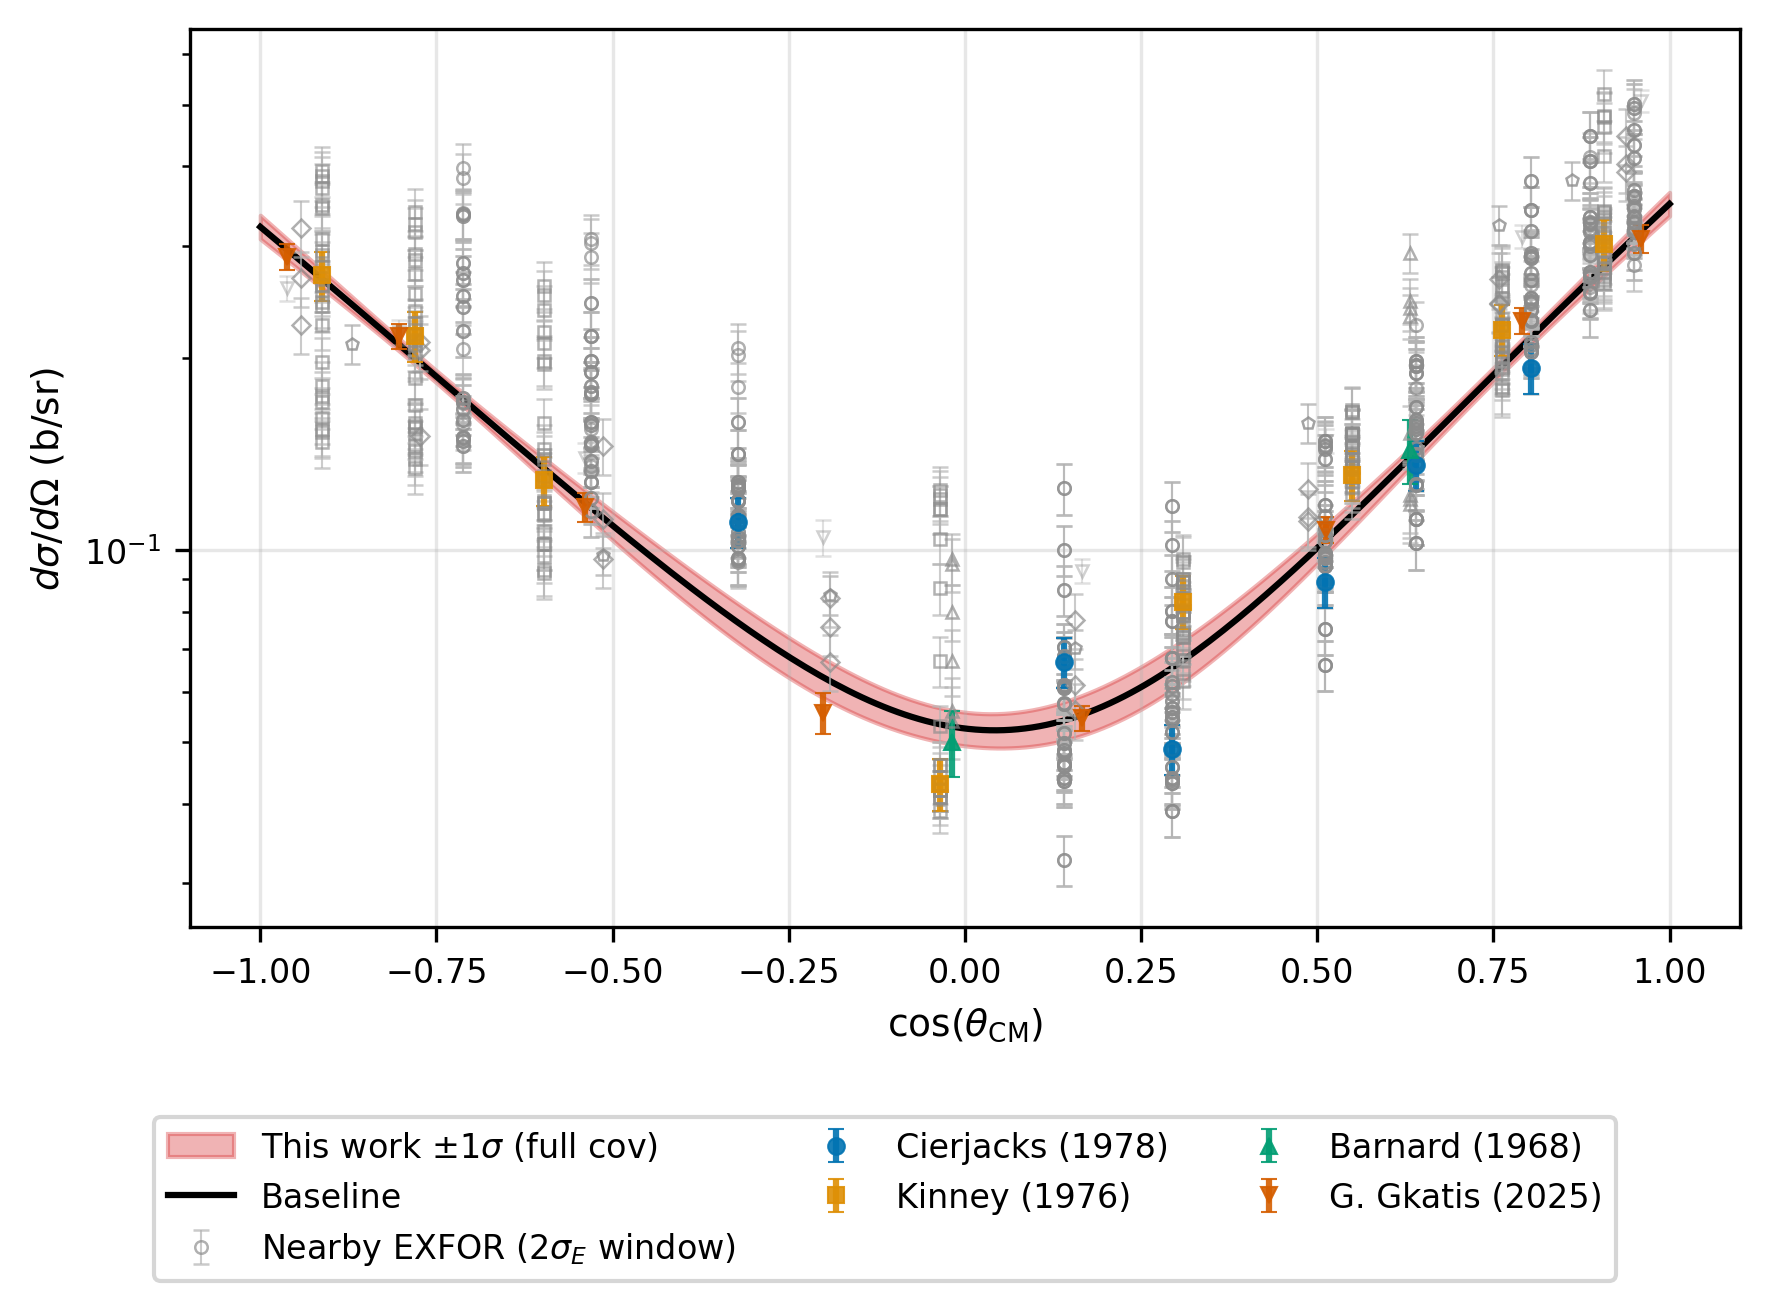

  Saved: /share_snc/snc/JuanMonleon/DA_Figures/E_1.17_MeV/This_work/summary_combined_linear.png


In [31]:
# --- Summary (combined band + EXFOR) ---
for key in case_keys:
    r = all_results[key]
    cd = case_exfor_data[key]
    color = CASE_COLORS[key]

    for yscale in ['log', 'linear']:
        fig = plot_summary(r, cd['exfor'], cd['exp_info'], key,
                           yscale=yscale, ext_data=ext_exfor_data.get(key),
                           band_color=color)
        save_figure_structured(fig, 'summary', library=key,
                               filename='summary_combined', yscale=yscale)
        if yscale == PLOT_YSCALE:
            plt.show()
        else:
            plt.close(fig)

## 11. Cross-Case Comparison

  Saved: /share_snc/snc/JuanMonleon/DA_Figures/E_1.17_MeV/comparison/cross_case_comparison_log.png


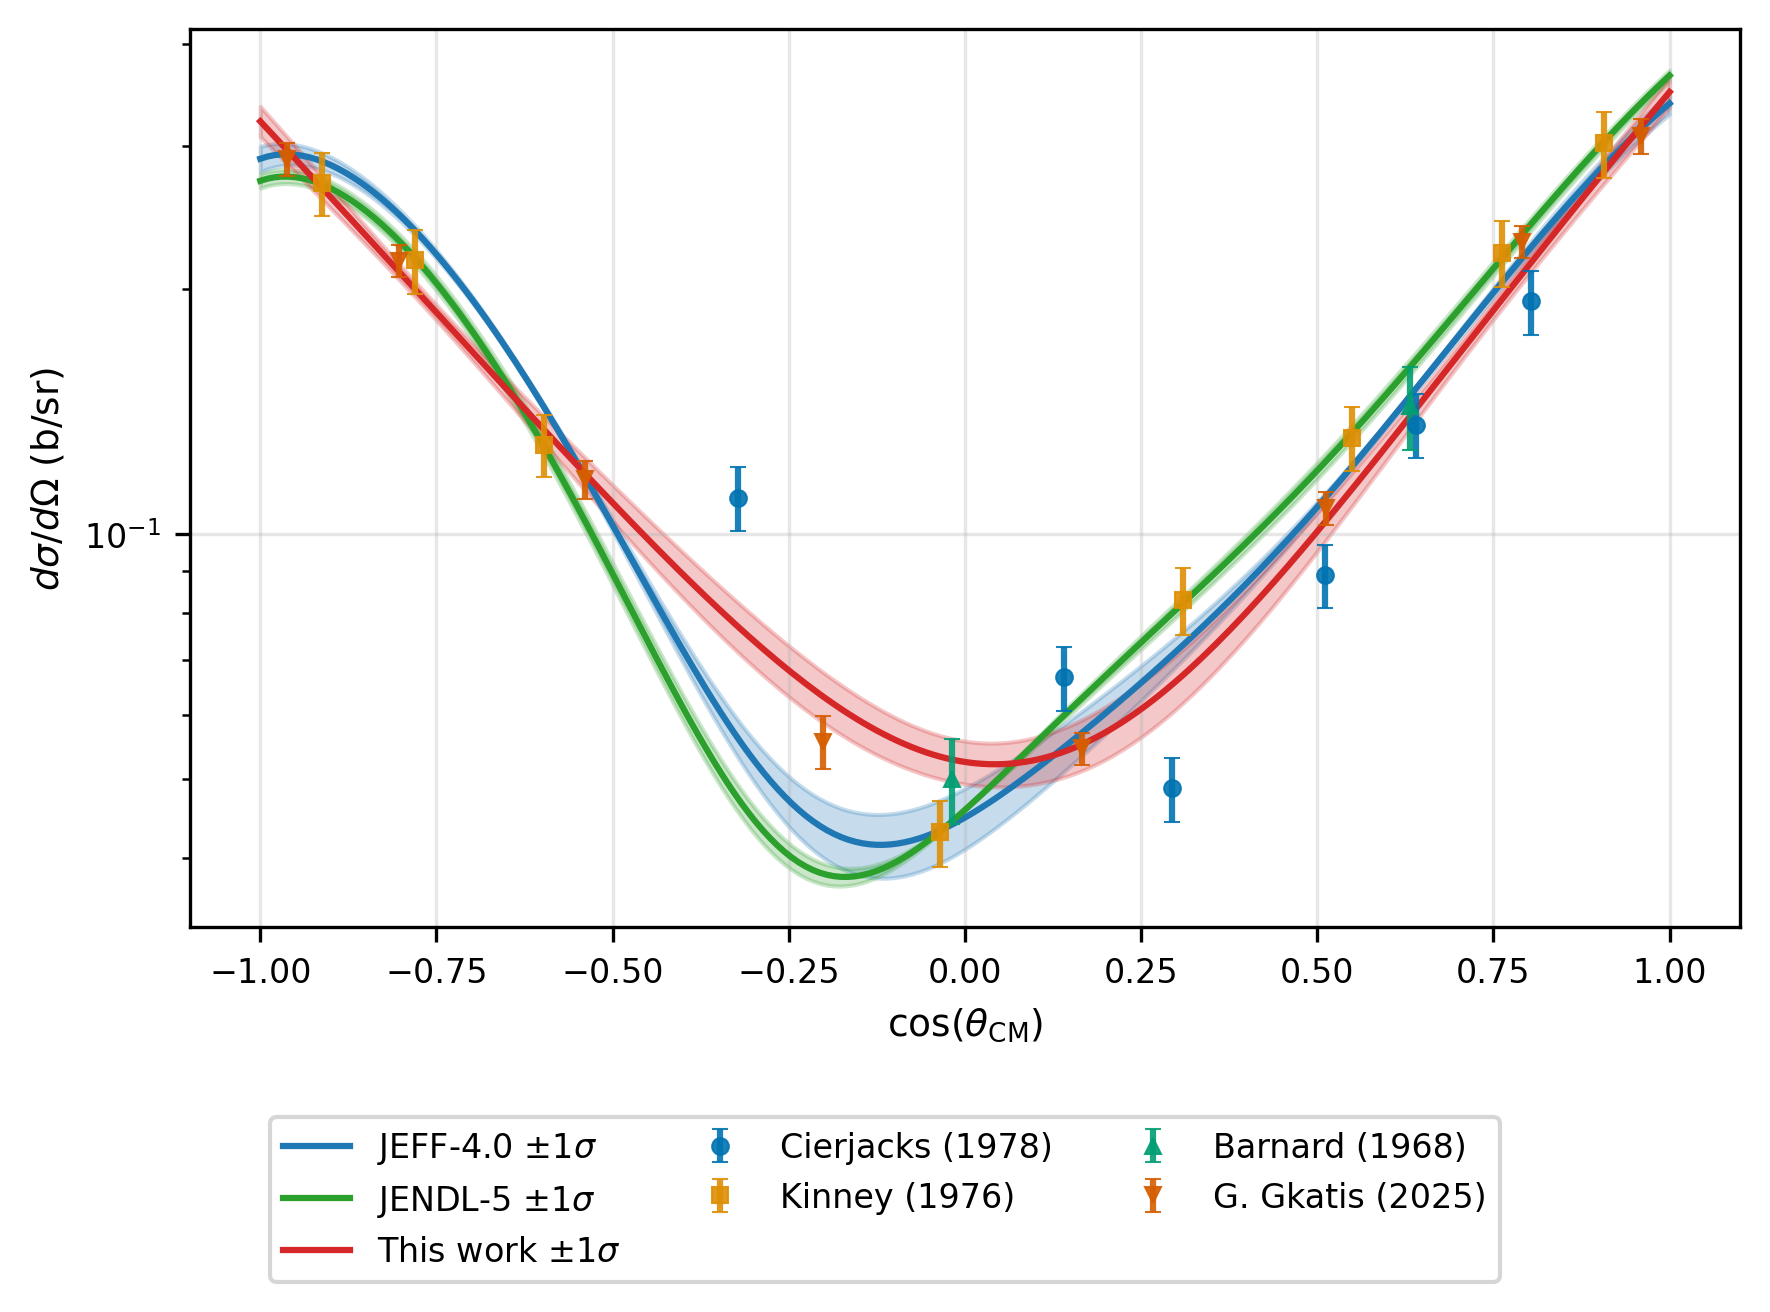

  Saved: /share_snc/snc/JuanMonleon/DA_Figures/E_1.17_MeV/comparison/cross_case_comparison_linear.png


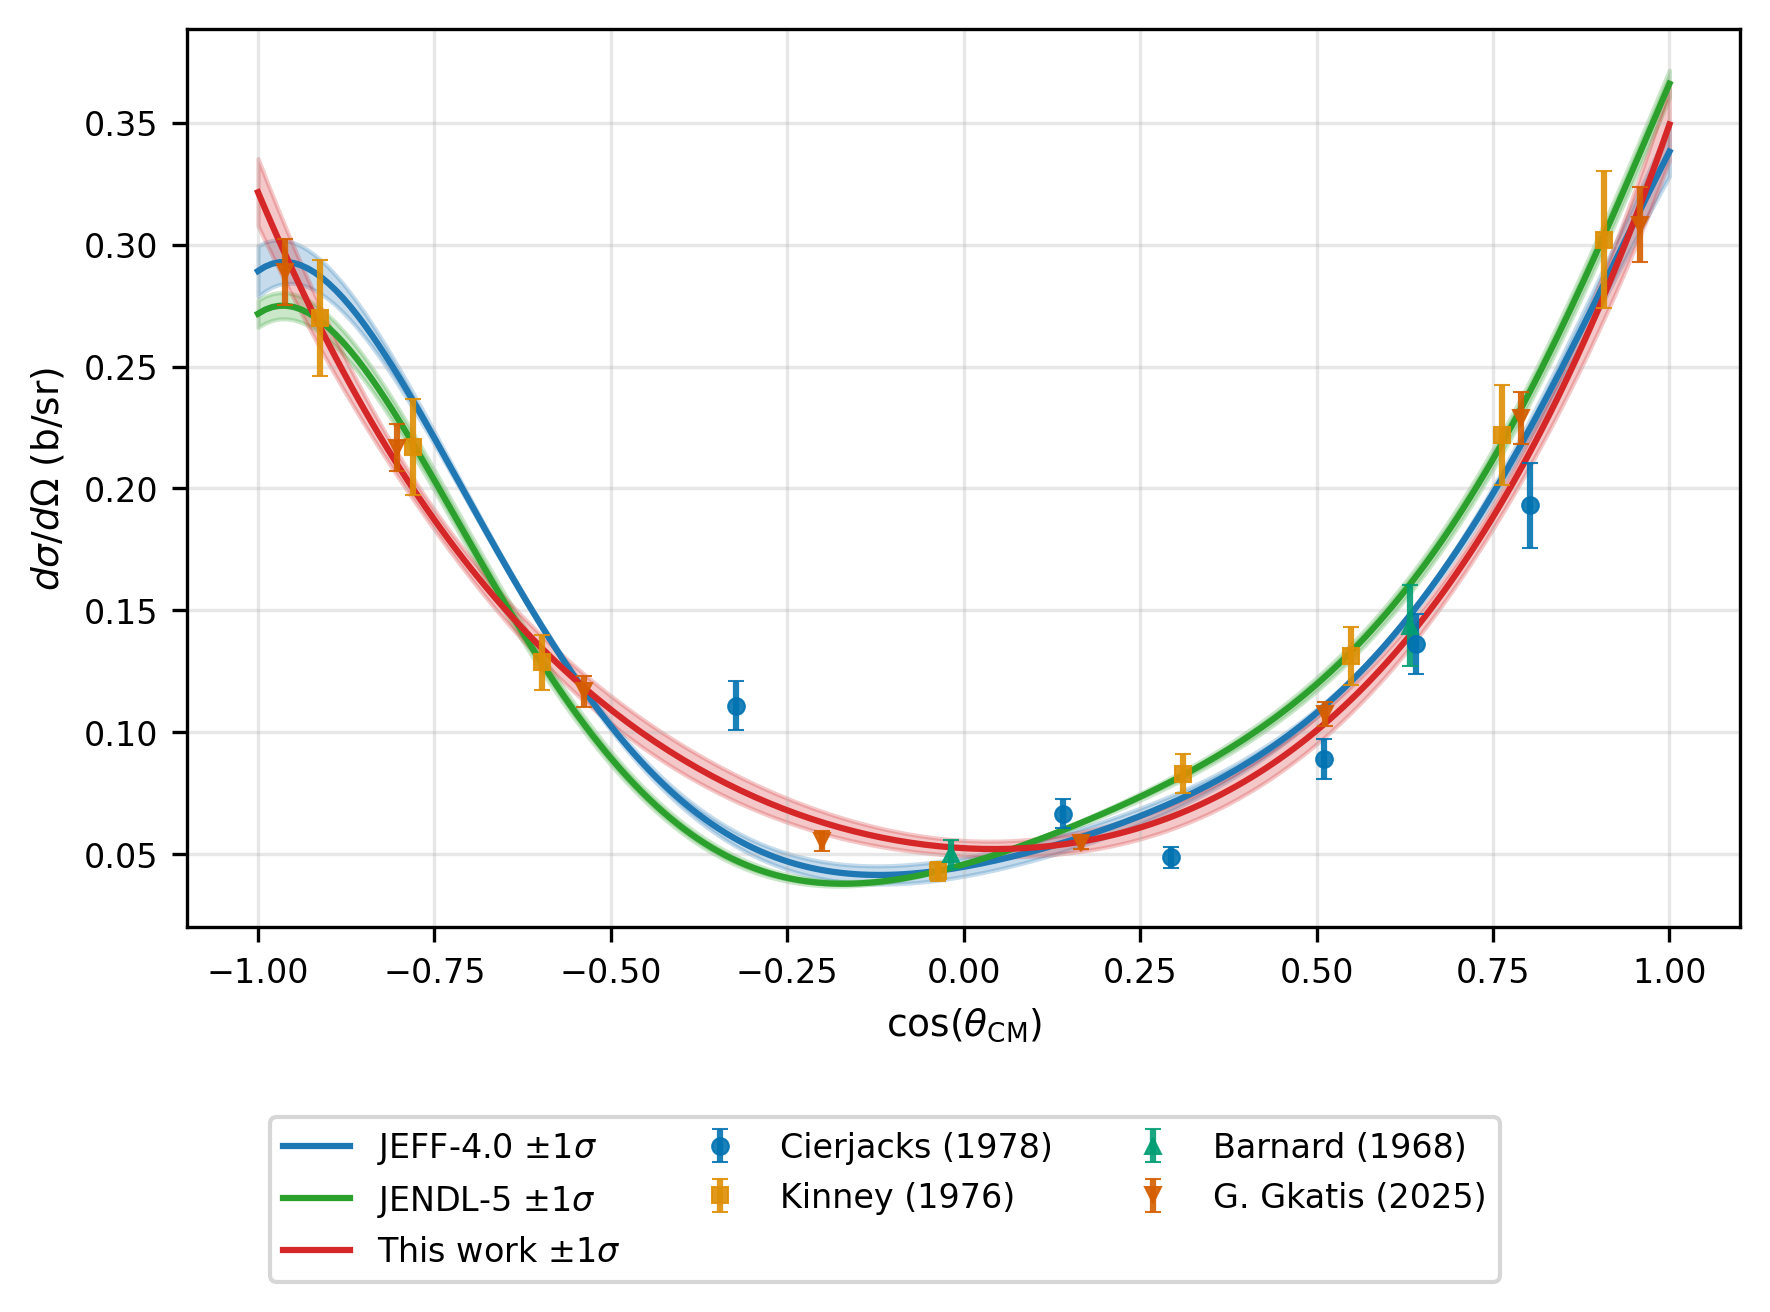

  Saved: /share_snc/snc/JuanMonleon/DA_Figures/E_1.17_MeV/comparison/cross_case_triptych_log.png


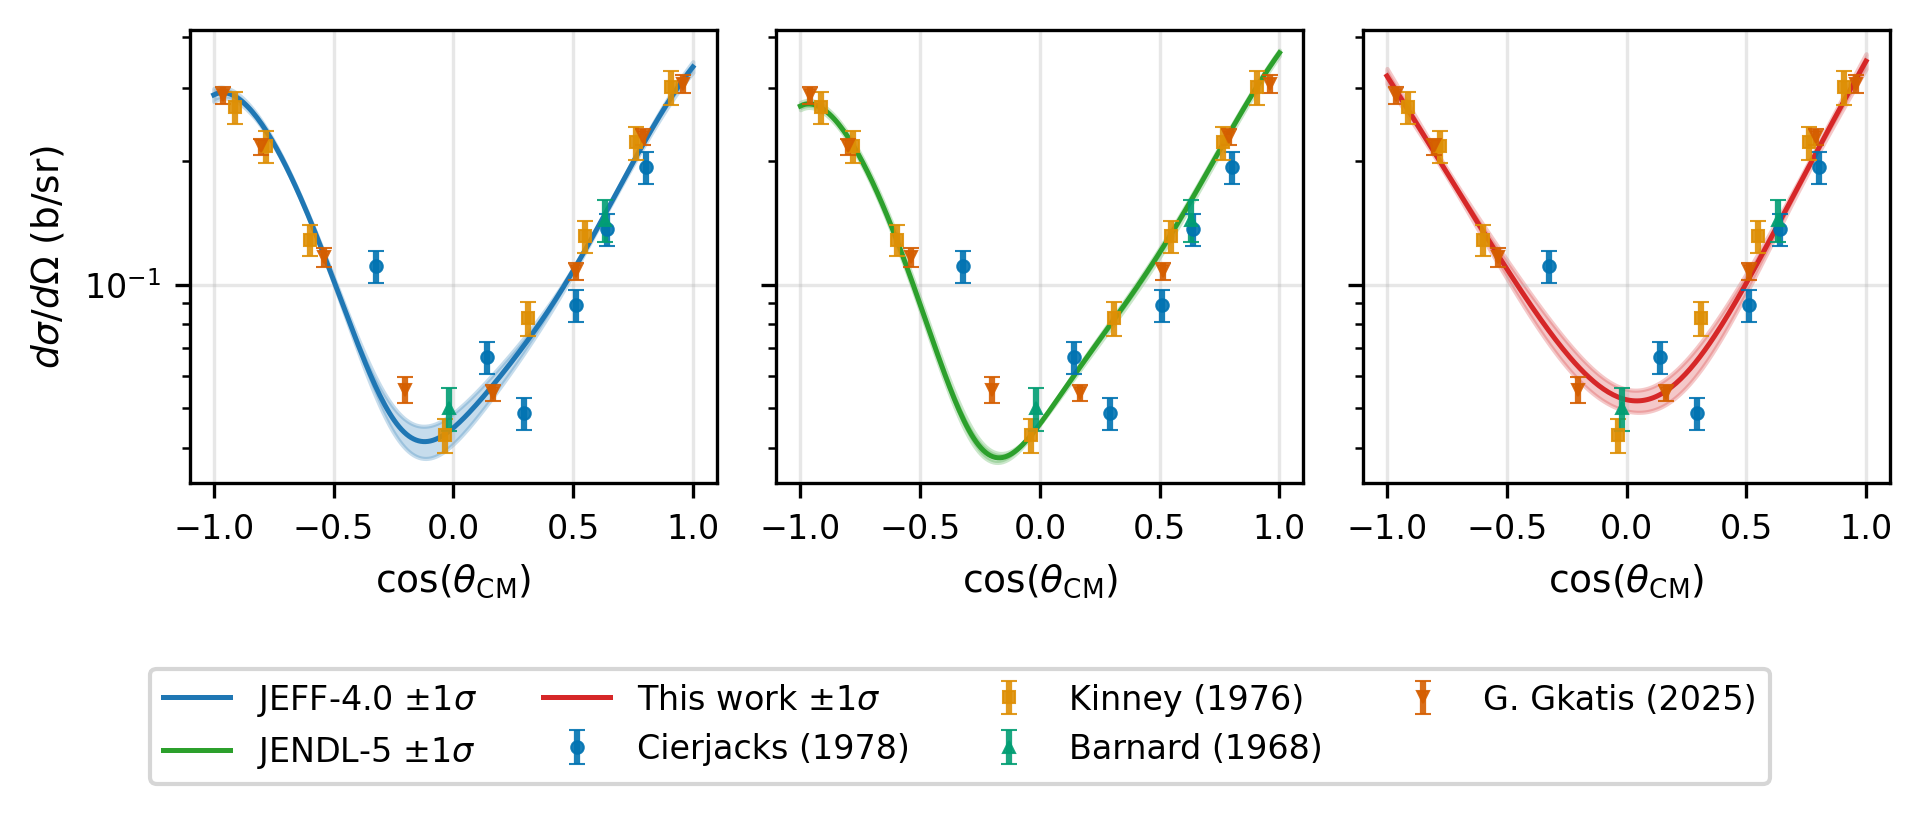

  Saved: /share_snc/snc/JuanMonleon/DA_Figures/E_1.17_MeV/comparison/cross_case_triptych_linear.png


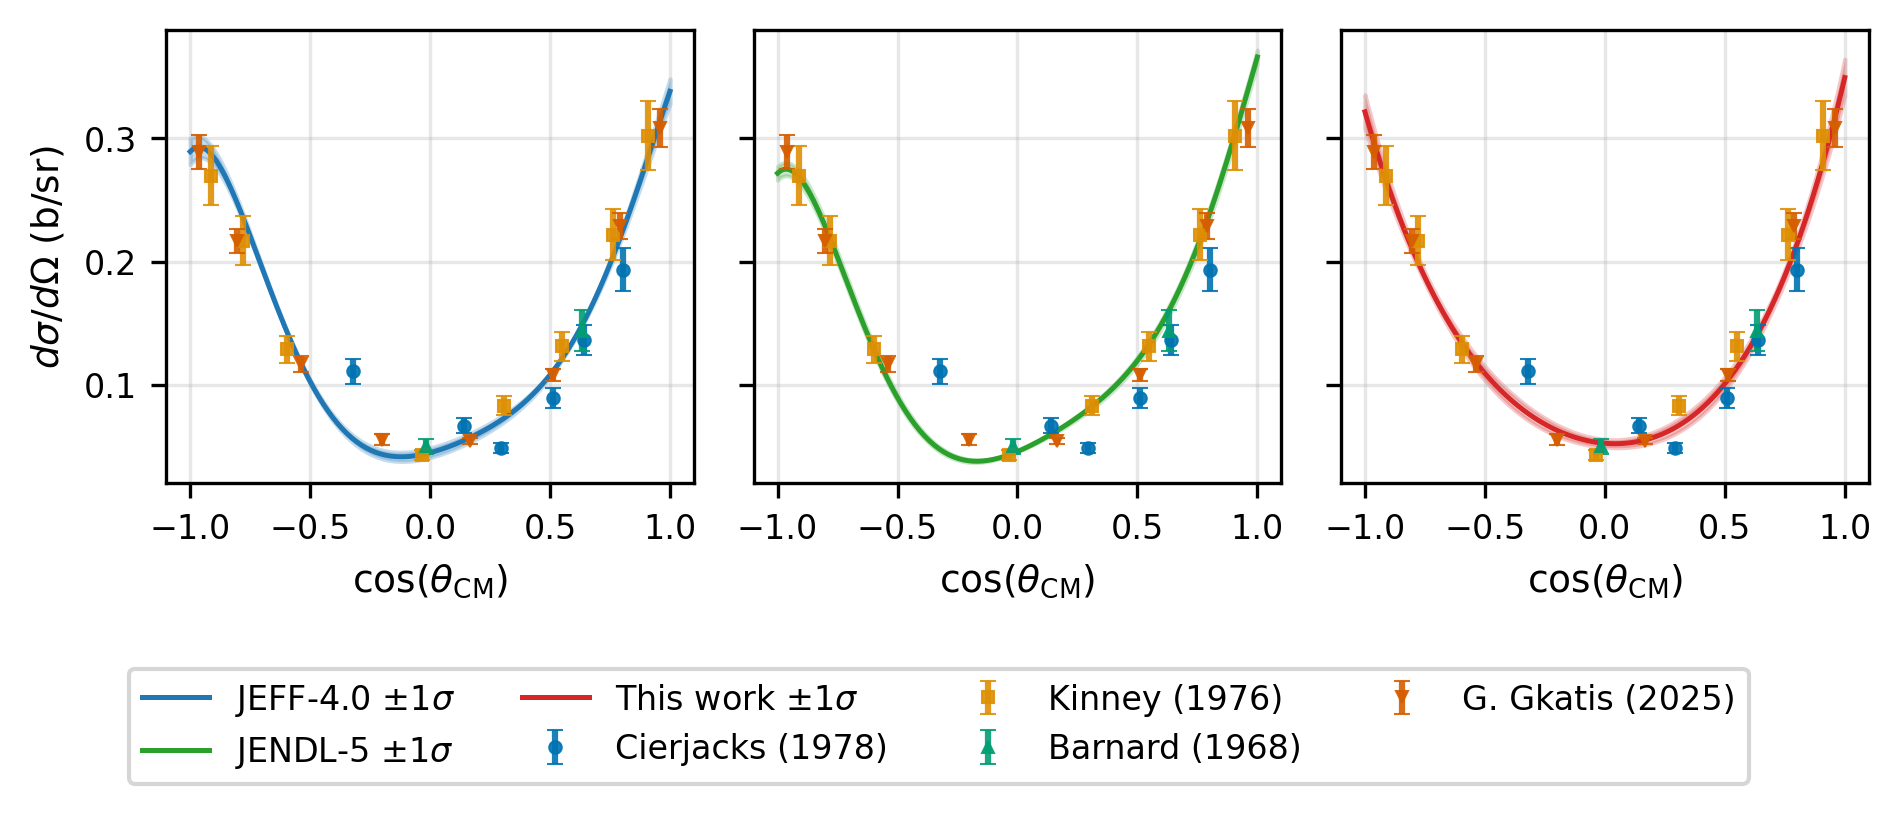

In [32]:
# --- Cross-case overlay: all libraries on one plot ---
for yscale in ['log', 'linear']:
    fig = plot_cross_case_comparison(
        all_results, case_keys, ext_exfor_data, yscale=yscale)
    save_figure_structured(fig, 'comparison',
                           filename='cross_case_comparison', yscale=yscale)
    plt.show()

# --- Cross-case triptych: 1x3 side-by-side (one library per panel) ---
for yscale in ['log', 'linear']:
    fig = plot_cross_case_triptych(
        all_results, case_keys, case_exfor_data,
        ext_exfor_data, yscale=yscale)
    save_figure_structured(fig, 'comparison',
                           filename='cross_case_triptych', yscale=yscale)
    plt.show()

## 12. Summary Statistics

In [33]:
print("=" * 72)
print(f"  MF34 Legendre Uncertainty Breakdown -- E = {TARGET_ENERGY_MEV} MeV")
print("=" * 72)

for key in ["JEFF-4.0", "JENDL-5", "This work"]:
    if key not in all_results:
        print(f"\n--- {key}: not available ---")
        continue
    r = all_results[key]
    fit = case_fits[key]
    da  = case_delta_a[key]
    endf_coeffs = case_endf_data[key]['endf_coeffs']

    print(f"\n--- {key} ---")
    print(f"  c0              : {r['c0']:.6f} b/sr")
    print(f"  L_max           : {r['L_max']}")
    chi2_info = fit.get('chi2_all') if fit else None
    if chi2_info is not None:
        print(f"  chi2/N          : {chi2_info['chi2/N']:.3f}  (combined sigma)")
        print(f"  chi2/N (exp)    : {chi2_info['chi2/N_exp_only']:.3f}  (exp-only sigma)")
        print(f"  N               : {chi2_info['N']}")
    else:
        print(f"  chi2            : not available")
    if fit and 'fit_info' in fit:
        print(f"  Birge scale     : {fit['fit_info']['scale_factor']:.2f}")
    print(f"  Max diag band   : {r['combined'].max():.4e} b/sr")
    print(f"  Max full-cov band: {r.get('combined_full', r['combined']).max():.4e} b/sr")
    if not np.allclose(r.get('combined_full', r['combined']), r['combined'], rtol=1e-6):
        ratio = r['combined_full'].max() / r['combined'].max()
        print(f"  Full/diag ratio : {ratio:.4f}")
    else:
        print(f"  Full/diag ratio : 1.0000 (no cross-correlations)")
    print(f"  da_l per order  :")
    for l in range(1, r['L_max'] + 1):
        da_abs = da.get(l, 0.0)
        a_l = endf_coeffs[l - 1] if l - 1 < len(endf_coeffs) else 0.0
        if abs(a_l) > 0:
            rel_pct = abs(da_abs / a_l) * 100
            print(f"    L={l}: da = {da_abs:.4e},  a_l = {a_l:.4e},  rel = {rel_pct:.1f}%")
        else:
            print(f"    L={l}: da = {da_abs:.4e},  a_l = {a_l:.4e},  rel = N/A (a_l=0)")

print("\n" + "=" * 72)

  MF34 Legendre Uncertainty Breakdown -- E = 1.171 MeV

--- JEFF-4.0 ---
  c0              : 0.136501 b/sr
  L_max           : 6
  chi2/N          : 3.540  (combined sigma)
  chi2/N (exp)    : 4.362  (exp-only sigma)
  N               : 24
  Birge scale     : 1.00
  Max diag band   : 8.9884e-03 b/sr
  Max full-cov band: 1.0426e-02 b/sr
  Full/diag ratio : 1.1600
  da_l per order  :
    L=1: da = 7.0731e-05,  a_l = -1.3196e-03,  rel = 5.4%
    L=2: da = 1.2589e-02,  a_l = 2.8768e-01,  rel = 4.4%
    L=3: da = 3.7313e-04,  a_l = -1.4581e-03,  rel = 25.6%
    L=4: da = 2.1285e-03,  a_l = 6.2959e-04,  rel = 338.1%
    L=5: da = 0.0000e+00,  a_l = 1.7589e-02,  rel = 0.0%
    L=6: da = 0.0000e+00,  a_l = -1.1248e-02,  rel = 0.0%

--- JENDL-5 ---
  c0              : 0.136501 b/sr
  L_max           : 6
  chi2/N          : 6.751  (combined sigma)
  chi2/N (exp)    : 7.505  (exp-only sigma)
  N               : 24
  Birge scale     : 1.00
  Max diag band   : 5.5695e-03 b/sr
  Max full-cov band: 5